In [1]:
import os
import glob
import json
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as cl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
from collections import defaultdict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    f1_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
)

In [2]:
def h5_to_dict(h5_path):
    data = defaultdict(dict)
    with h5py.File(h5_path, 'r') as f:
        data['start_time'] = f.attrs['start_time']

        if 'ahi' in f.attrs.keys():
            data['ahi'] = f.attrs['ahi']
        
        if np.any([f'{stage}_hours' in f.attrs.keys() for stage in ['wake', 'n1', 'n2', 'n3', 'rem']]):
            stages = {
                'wake': 0,
                'n1': 0,
                'n2': 0,
                'n3': 0,
                'rem': 0,
                'missing': 0,
            }

            for stage in stages.keys():
                if f'{stage}_hours' in f.attrs.keys():
                    stages[stage] = f.attrs[f'{stage}_hours']
            data['stages_hours'] = stages
        
        data['accelerometry'] = np.array(f['data/accelerometry'])
        data['hypnogram'] = np.array(f['annotations/hypnogram'])

    return data

def safe_cw_auc(targets, scores, mode = 'ovo', count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)
    unique_targets = unique_targets[counts > count_lim]
    cw_auc = np.full(scores.shape[-1], np.nan)
    if len(unique_targets) == 1:
        return cw_auc
    for k in unique_targets:
        if mode == 'ovo':
            cw_auc[k] = 0
            for l in unique_targets:
                if l == k: continue
                tmp_mask = np.logical_or(targets == k, targets == l)
                tmp_targets = targets[tmp_mask]
                tmp_scores = scores[tmp_mask, k]
                cw_auc_kvl = roc_auc_score(tmp_targets == k,tmp_scores)
                cw_auc[k] += cw_auc_kvl/(len(unique_targets -1))
        elif mode == 'ovr':
            cw_auc[k] = roc_auc_score(targets == k, scores[:, k])
        else:
            raise "Mode must be ovo or ovr"
    return cw_auc

def safe_cw_pr_re_f1(targets, preds, num_classes, count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)

    # Target count filter
    count_filt = np.full(num_classes, np.nan)
    count_filt[unique_targets[counts > count_lim]] = 1 

    # Calculate scores (results will only include present targets)
    cw_prec = precision_score(targets, preds, average=None, zero_division=np.nan)
    cw_rec = recall_score(targets, preds, average=None, zero_division=np.nan)
    cw_f1 = f1_score(targets, preds, average=None, zero_division=np.nan)

    # Initialize NaN arrays to fill to make sure all possible targets are representet
    cw_prec_array = np.full(num_classes, np.nan)
    cw_rec_array = np.full(num_classes, np.nan)
    cw_f1_array = np.full(num_classes, np.nan)

    # Fill in NaN arrays
    for i, k in enumerate(unique_targets):
        cw_prec_array[k] = cw_prec[i] * count_filt[i]
        cw_rec_array[k] = cw_rec[i] * count_filt[i]
        cw_f1_array[k] = cw_f1[i] * count_filt[i]

    return cw_prec_array, cw_rec_array, cw_f1_array

def calc_sleep_summary_metrics(stages, label_map):
    metrics = {}
    # Calculate TST
    sleep = stages != label_map['wake']
    tst = (sleep).sum()
    metrics['tst'] = float(tst)
    
    try:
        # Calculate SOL (first consecutive 3-epoch sleep window)
        # [[sleep, False, False],
        # [False, sleep, False],
        # [False, False, sleep]]
        sleep_shifted = np.stack([
            np.append(sleep, [False, False]),
            np.insert(np.append(sleep, [False]), 0, [False]),
            np.insert(sleep, 0, [False, False]),
        ])
        sol = np.argwhere(sleep_shifted.all(axis=0)).min()
        metrics['sol'] = float(sol)

        # Calculate WASO, how to handle missing?
        # Trim back from the last index if it is wake
        # Find last index of sleep 
        last_sleep = np.argwhere(stages != label_map['wake']).max() + 1
        waso = (stages[sol: last_sleep] == label_map['wake']).sum()
        metrics['waso'] = float(waso)
    except:
        metrics['sol'] = np.nan
        metrics['waso'] = np.nan
    # Calculate SE
    # se = (stages[sol: last_sleep] != label_map['wake']).sum() / (last_sleep - sol)
    se = (stages != label_map['wake']).sum() / len(stages)
    metrics['se'] = float(se)

    # Calculate REM
    rem = (stages == ss_label_map['rem']).sum()
    metrics['rem'] = float(rem)
    
    # Calculate Deep
    deep = (stages == ss_label_map['deep']).sum()
    metrics['deep'] = float(deep)

    # Calculate Light
    light = (stages == ss_label_map['light']).sum()
    metrics['light'] = float(light)

    # Calculate NREM
    nrem = light + deep
    metrics['nrem'] = float(nrem)

    return metrics


In [3]:
ss_labels_name = 'light_deep_rem'
ss_label_map = {
    'deep': 0,
    'light': 1,
    'rem': 2,
    'wake': 3,
    'missing': -9,
}
# ss_label_map_inv = {val: key for key, val in ss_label_map.items()}
ss_label_map_inv = {val: key for key, val in ss_label_map.items() if val != -9}
ss_label_order = ['wake', 'light', 'deep', 'rem']
ss_label_name = ['Wake', 'Light', 'Deep', 'REM']

nrem_label_name = ['Wake', 'NREM', 'REM']
rem_nrem_label_map = {
    'NREM': 0,
    'REM': 1,
    'Wake': 2,
    'missing': -9,
}
rem_nrem_label_map_inv = {val: key for key, val in rem_nrem_label_map.items() if val != -9}

sleep_label_name = ['Wake', 'Sleep']
sleep_label_map = {
    'Sleep': 0,
    'Wake': 1,
    'missing': -9,
}
sleep_label_map_inv = {val: key for key, val in sleep_label_map.items() if val != -9}

ss_colormap = {
    'wake': 'tab:red',
    'Wake': 'tab:red',
    'light': 'tab:orange',
    'Light': 'tab:orange',
    'deep': 'tab:blue',
    'Deep': 'tab:blue',
    'rem': 'tab:green',
    'REM': 'tab:green',
}
ss_case_map = {
    'wake':'Wake',
    'light': 'Light',
    'deep': 'Deep',
    'rem': 'REM',
}

dset_map = {
    'newcastle_left': 'Newcastle',
    'newcastle_right': 'Newcastle',
    'stages': 'STAGES',
    'dreamt': 'DREAMT',
    'tbi': 'TBI',
    'amazfit': 'Health',
    'sleepaccel': 'SleepAccel',
}

In [4]:
## Subject-wise performance metrics
cw_precs = defaultdict(list)
cw_recalls = defaultdict(list)
cw_f1s = defaultdict(list)
cw_aucs = defaultdict(list)
roc_curves = defaultdict(list)
macro_results = defaultdict(list)
soft_preds_all = []
targets_all = []
preds_all = []

summary_diffs = defaultdict(list)
summary_means = defaultdict(list)
summary_preds = defaultdict(list)
summary_targets = defaultdict(list)

cw_precs_nrem = defaultdict(list)
cw_recalls_nrem = defaultdict(list)
cw_f1s_nrem = defaultdict(list)
macro_results_nrem = defaultdict(list)
soft_preds_all_nrem = []
targets_all_nrem = []
preds_all_nrem = []

cw_precs_sleep = defaultdict(list)
cw_recalls_sleep = defaultdict(list)
cw_f1s_sleep = defaultdict(list)
macro_results_sleep = defaultdict(list)

exp_i = []
subject_i = []
dataset_i = []
int_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_internal'
ext_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_external'
# lstmc_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_internal'
# lstmc_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_external'
# lin_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_external_2'
# lstmc_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_external_2'
# lin_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_tp/tp_1.0'
# lstmc_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_tp/tp_1.0'
experiments = [('Internal', int_path), ('External', ext_path)]
for exp_name, experiment_dir in experiments:
    for dataset in os.scandir(experiment_dir):
        for sub_dir in os.scandir(dataset):
            subject_i.append(os.path.basename(sub_dir))
            dataset_i.append(os.path.basename(dataset))
            exp_i.append(exp_name)

            missing_idx = ss_label_map['missing']

            scores = np.load(os.path.join(sub_dir.path + '/soft_preds.npy'))
            targets = np.load(os.path.join(sub_dir.path + '/targets.npy'))

            scores = scores[targets != missing_idx]
            targets = targets[targets != missing_idx]

            # Excluded NaNs due to signal dropout in AccelSleep
            nan_mask = np.isnan(scores).any(-1)
            scores = scores[~nan_mask]
            targets = targets[~nan_mask]

            # Get hard predictions
            preds = scores.argmax(axis=-1)

            soft_preds_all.append(np.copy(scores))
            targets_all.append(np.copy(targets))
            preds_all.append(np.copy(preds))
 
            unique_targets, counts = np.unique(targets, return_counts=True)
            unique_preds, pred_counts = np.unique(preds, return_counts=True)
       
            ## Subject-wise class-wise scores
            # Precision, Recall, and F1
            cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=scores.shape[-1], count_lim=3)
            
            # Manually compute binary AUC for each label present (NaN for non-valid)
            cw_auc = safe_cw_auc(targets, scores, mode='ovr', count_lim=3)

            for k in range(scores.shape[-1]):
                cw_aucs[ss_label_map_inv[k]].append(float(cw_auc[k]))
                cw_precs[ss_label_map_inv[k]].append(float(cw_pr[k]))
                cw_recalls[ss_label_map_inv[k]].append(float(cw_re[k]))
                cw_f1s[ss_label_map_inv[k]].append(float(cw_f1[k]))

            # Class-wise ROC curves
            for k in unique_targets:
                roc = roc_curve(targets, scores[:,k], pos_label=k)
                roc_curves[ss_label_map_inv[k]].append(roc)
            
            ## Subject-wise macro averages
            mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
            mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
            mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
            accuracy = accuracy_score(targets, preds)

            kappa = cohen_kappa_score(targets, preds)
            macro_results['Precision'].append(mac_prec)
            macro_results['Recall'].append(mac_rec)
            macro_results['F1'].append(mac_f1)
            macro_results['Kappa'].append(kappa)
            macro_results['Accuracy'].append(accuracy)
            macro_results['AUROC'].append(np.nanmean(cw_auc))

            # Sleep summary metrics for bland-altmann
            pred_metrics = calc_sleep_summary_metrics(preds, ss_label_map)
            target_metrics = calc_sleep_summary_metrics(targets, ss_label_map)
            summary_diff_ = {
                f'{key}': pred_metrics[key] - target_metrics[key]
                for key in pred_metrics.keys()
            }
            summary_mean_ = {
                f'{key}': (pred_metrics[key] + target_metrics[key])/2
                for key in pred_metrics.keys()                 
            }
            summary_pred_ = {
                f'{key}': pred_metrics[key]
                for key in pred_metrics.keys()
            }
            summary_target_ = {
                f'{key}': target_metrics[key]
                for key in pred_metrics.keys()
            }
            for key in pred_metrics.keys():
                summary_diffs[key].append(summary_diff_[key])
                summary_means[key].append(summary_mean_[key])
                summary_preds[key].append(summary_pred_[key])
                summary_targets[key].append(summary_target_[key])
            
            ### REM-NREM label set evaluation
            preds[preds==1] = 0
            preds[preds==2] = 1
            preds[preds==3] = 2
  
            targets[targets==1] = 0
            targets[targets==2] = 1
            targets[targets==3] = 2

            soft_preds_all_nrem.append(np.copy(scores))
            targets_all_nrem.append(np.copy(targets))
            preds_all_nrem.append(np.copy(preds))

            ## Subject-wise macro averages
            mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
            mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
            mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
            accuracy = accuracy_score(targets, preds)
            kappa = cohen_kappa_score(targets, preds)
            macro_results_nrem['Precision'].append(mac_prec)
            macro_results_nrem['Recall'].append(mac_rec)
            macro_results_nrem['F1'].append(mac_f1)
            macro_results_nrem['Kappa'].append(kappa)
            macro_results_nrem['Accuracy'].append(accuracy)

            cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=3, count_lim=3)
            for k in range(3):
                cw_precs_nrem[rem_nrem_label_map_inv[k]].append(float(cw_pr[k]))
                cw_recalls_nrem[rem_nrem_label_map_inv[k]].append(float(cw_re[k]))
                cw_f1s_nrem[rem_nrem_label_map_inv[k]].append(float(cw_f1[k]))

            ### Sleep-wake label set evaluation
            preds[preds==1] = 0
            preds[preds==2] = 1
  
            targets[targets==1] = 0
            targets[targets==2] = 1

            ## Subject-wise macro averages
            mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
            mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
            mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
            kappa = cohen_kappa_score(targets, preds)
            accuracy = accuracy_score(targets, preds)
            macro_results_sleep['Precision'].append(mac_prec)
            macro_results_sleep['Recall'].append(mac_rec)
            macro_results_sleep['F1'].append(mac_f1)
            macro_results_sleep['Kappa'].append(kappa)
            macro_results_sleep['Accuracy'].append(accuracy)          

            cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=3, count_lim=3)
            for k in range(2):
                cw_precs_sleep[sleep_label_map_inv[k]].append(float(cw_pr[k]))
                cw_recalls_sleep[sleep_label_map_inv[k]].append(float(cw_re[k]))
                cw_f1s_sleep[sleep_label_map_inv[k]].append(float(cw_f1[k]))


macro_results = pd.DataFrame(data=macro_results)
cw_aucs = pd.DataFrame(data=cw_aucs)
cw_precs = pd.DataFrame(data=cw_precs)
cw_recalls = pd.DataFrame(data=cw_recalls)
cw_f1s = pd.DataFrame(data=cw_f1s)
summary_means = pd.DataFrame(data=summary_means)
summary_diffs = pd.DataFrame(data=summary_diffs)
summary_preds = pd.DataFrame(data=summary_preds)
summary_targets = pd.DataFrame(data=summary_targets)

for col in summary_means.columns:
    if col == 'se':
        factor = 100 # fraction to %
    else:
        factor = 0.5 # 30s epoch to minutes
    summary_diffs[col] = summary_diffs[col] * factor
    summary_means[col] = summary_means[col] * factor
    summary_preds[col] = summary_preds[col] * factor  
    summary_targets[col] = summary_targets[col] * factor

macro_results_nrem = pd.DataFrame(data=macro_results_nrem)
cw_precs_nrem = pd.DataFrame(data=cw_precs_nrem)
cw_recalls_nrem = pd.DataFrame(data=cw_recalls_nrem)
cw_f1s_nrem = pd.DataFrame(data=cw_f1s_nrem)

macro_results_sleep = pd.DataFrame(data=macro_results_sleep)
cw_precs_sleep = pd.DataFrame(data=cw_precs_sleep)
cw_recalls_sleep = pd.DataFrame(data=cw_recalls_sleep)
cw_f1s_sleep = pd.DataFrame(data=cw_f1s_sleep)

In [5]:
macro_table = macro_results.copy()
macro_table['Model'] = exp_i
macro_table['Dataset'] = dataset_i
macro_table['Dataset'] = macro_table['Dataset'].map(dset_map)

macro_table_overall = macro_table.copy()
macro_table_overall['Dataset'] = 'Overall'
overall_notbi = macro_table_overall[macro_table['Dataset'] != 'TBI'].copy()
overall_notbi['Dataset'] = 'Overall w/o TBI'
macro_table = pd.concat([macro_table, macro_table_overall, overall_notbi])

sd_df = macro_table.groupby(['Dataset', 'Model']).std()
mean_df = macro_table.groupby(['Dataset', 'Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall w/o TBI','Overall']]
rest = new_df.drop(['Overall w/o TBI','Overall'], level="Dataset")
new_df = pd.concat([rest, overall])
new_df

Precision         Recall             F1  \
Dataset         Model                                                   
DREAMT          Internal    0.451 ± 0.1  0.564 ± 0.144  0.413 ± 0.116   
Health          External  0.541 ± 0.131  0.614 ± 0.125  0.491 ± 0.131   
Newcastle       Internal  0.462 ± 0.134   0.464 ± 0.13   0.402 ± 0.12   
STAGES          Internal  0.491 ± 0.076  0.518 ± 0.076   0.47 ± 0.083   
SleepAccel      External  0.498 ± 0.073  0.561 ± 0.116  0.431 ± 0.086   
TBI             Internal  0.505 ± 0.106  0.538 ± 0.132  0.443 ± 0.142   
Overall w/o TBI External  0.525 ± 0.114  0.594 ± 0.123  0.468 ± 0.119   
                Internal  0.461 ± 0.107  0.528 ± 0.137   0.42 ± 0.114   
Overall         External  0.525 ± 0.114  0.594 ± 0.123  0.468 ± 0.119   
                Internal  0.474 ± 0.109  0.531 ± 0.135  0.427 ± 0.123   

                                  Kappa       Accuracy          AUROC  
Dataset         Model                                                  
DREAMT          Internal  0.305 ± 0.167  0.557 ± 0.126  0.792 ± 0.103  
Health          External  0.359 ± 0.156   0.513 ± 0.12  0.831 ± 0.099  
Newcastle       Internal  0.226 ± 0.132  0.471 ± 0.116  0.712 ± 0.112  
STAGES          Internal   0.334 ± 0.11  0.559 ± 0.069  0.782 ± 0.067  
SleepAccel      External  0.242 ± 0.096   0.417 ± 0.09   0.801 ± 0.06  
TBI             Internal  0.307 ± 0.166    0.5 ± 0.144  0.785 ± 0.107  
Overall w/o TBI External  0.315 ± 0.147  0.477 ± 0.119   0.82 ± 0.087  
                Internal  0.288 ± 0.153  0.533 ± 0.121  0.768 ± 0.106  
Overall         External  0.315 ± 0.147  0.477 ± 0.119   0.82 ± 0.087  
                Internal  0.293 ± 0.157  0.523 ± 0.129  0.773 ± 0.106

In [6]:
macro_table = macro_results_nrem.copy()
macro_table['Model'] = exp_i
macro_table['Dataset'] = dataset_i
macro_table['Dataset'] = macro_table['Dataset'].map(dset_map)

macro_table_overall = macro_table.copy()
macro_table_overall['Dataset'] = 'Overall'
overall_notbi = macro_table_overall[macro_table['Dataset'] != 'TBI'].copy()
overall_notbi['Dataset'] = 'Overall w/o TBI'
macro_table = pd.concat([macro_table, macro_table_overall, overall_notbi])

sd_df = macro_table.groupby(['Dataset', 'Model']).std()
mean_df = macro_table.groupby(['Dataset', 'Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall w/o TBI','Overall']]
rest = new_df.drop(['Overall w/o TBI','Overall'], level="Dataset")
new_df = pd.concat([rest, overall])
new_df

Precision         Recall             F1  \
Dataset         Model                                                   
DREAMT          Internal  0.566 ± 0.115  0.637 ± 0.127  0.546 ± 0.132   
Health          External   0.671 ± 0.15  0.722 ± 0.149  0.661 ± 0.166   
Newcastle       Internal  0.524 ± 0.143  0.542 ± 0.133  0.481 ± 0.143   
STAGES          Internal  0.587 ± 0.066  0.604 ± 0.094    0.57 ± 0.08   
SleepAccel      External  0.641 ± 0.094   0.67 ± 0.141  0.627 ± 0.115   
TBI             Internal     0.61 ± 0.1  0.629 ± 0.131  0.563 ± 0.133   
Overall w/o TBI External   0.66 ± 0.132  0.702 ± 0.147  0.648 ± 0.148   
                Internal  0.558 ± 0.118   0.604 ± 0.13  0.532 ± 0.132   
Overall         External   0.66 ± 0.132  0.702 ± 0.147  0.648 ± 0.148   
                Internal  0.574 ± 0.116   0.612 ± 0.13  0.541 ± 0.132   

                                  Kappa       Accuracy  
Dataset         Model                                   
DREAMT          Internal  0.365 ± 0.187  0.647 ± 0.121  
Health          External  0.532 ± 0.226  0.731 ± 0.138  
Newcastle       Internal  0.263 ± 0.194  0.587 ± 0.144  
STAGES          Internal  0.371 ± 0.125  0.653 ± 0.069  
SleepAccel      External   0.47 ± 0.191  0.756 ± 0.099  
TBI             Internal  0.405 ± 0.193   0.678 ± 0.14  
Overall w/o TBI External  0.509 ± 0.214   0.74 ± 0.125  
                Internal  0.337 ± 0.184  0.631 ± 0.123  
Overall         External  0.509 ± 0.214   0.74 ± 0.125  
                Internal  0.358 ± 0.189   0.645 ± 0.13

In [7]:
macro_table = macro_results_sleep.copy()
macro_table['Model'] = exp_i
macro_table['Dataset'] = dataset_i
macro_table['Dataset'] = macro_table['Dataset'].map(dset_map)

macro_table_overall = macro_table.copy()
macro_table_overall['Dataset'] = 'Overall'
overall_notbi = macro_table_overall[macro_table['Dataset'] != 'TBI'].copy()
overall_notbi['Dataset'] = 'Overall w/o TBI'
macro_table = pd.concat([macro_table, macro_table_overall, overall_notbi])

sd_df = macro_table.groupby(['Dataset', 'Model']).std()
mean_df = macro_table.groupby(['Dataset', 'Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall w/o TBI','Overall']]
rest = new_df.drop(['Overall w/o TBI','Overall'], level="Dataset")
new_df = pd.concat([rest, overall])
new_df

Precision         Recall             F1  \
Dataset         Model                                                   
DREAMT          Internal  0.724 ± 0.113  0.752 ± 0.113  0.709 ± 0.116   
Health          External  0.834 ± 0.109  0.839 ± 0.103   0.82 ± 0.122   
Newcastle       Internal    0.68 ± 0.13   0.67 ± 0.114  0.643 ± 0.135   
STAGES          Internal  0.817 ± 0.094  0.817 ± 0.095    0.797 ± 0.1   
SleepAccel      External  0.732 ± 0.083  0.753 ± 0.095  0.722 ± 0.071   
TBI             Internal   0.76 ± 0.105  0.735 ± 0.108  0.709 ± 0.129   
Overall w/o TBI External  0.796 ± 0.111  0.807 ± 0.108  0.783 ± 0.116   
                Internal  0.728 ± 0.123    0.74 ± 0.12  0.705 ± 0.129   
Overall         External  0.796 ± 0.111  0.807 ± 0.108  0.783 ± 0.116   
                Internal  0.737 ± 0.119  0.738 ± 0.116  0.707 ± 0.128   

                                  Kappa       Accuracy  
Dataset         Model                                   
DREAMT          Internal  0.436 ± 0.212  0.801 ± 0.125  
Health          External  0.652 ± 0.218  0.859 ± 0.108  
Newcastle       Internal  0.319 ± 0.236  0.762 ± 0.152  
STAGES          Internal  0.604 ± 0.187    0.86 ± 0.08  
SleepAccel      External  0.448 ± 0.139  0.916 ± 0.027  
TBI             Internal   0.45 ± 0.204  0.814 ± 0.121  
Overall w/o TBI External  0.575 ± 0.215   0.88 ± 0.091  
                Internal  0.432 ± 0.233     0.8 ± 0.13  
Overall         External  0.575 ± 0.215   0.88 ± 0.091  
                Internal  0.437 ± 0.224  0.804 ± 0.127

In [8]:
cw_f1s['Score'] = 'F1'
cw_precs['Score'] = 'Precision'
cw_recalls['Score'] = 'Recall'
cw_aucs['Score'] = 'AUROC'
for table in [cw_f1s, cw_precs, cw_recalls, cw_aucs]:
    table['Model'] = exp_i
    table['Dataset'] = dataset_i
    table['Dataset'] = table['Dataset'].map(dset_map)
cw_scores = pd.concat([cw_f1s, cw_precs, cw_recalls, cw_aucs]).rename(columns=ss_case_map)
table = cw_scores.copy()
    
table_overall = table.copy()
table_overall['Dataset'] = 'Overall'
table = pd.concat([table, table_overall])

sd_df = table.groupby(['Dataset','Score','Model']).std()
mean_df = table.groupby(['Dataset', 'Score','Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall']]
rest = new_df.drop('Overall', level="Dataset")
new_df = pd.concat([rest, overall])
new_df.loc[['Health']]

Deep          Light            REM  \
Dataset Score     Model                                                   
Health  AUROC     External  0.846 ± 0.125  0.738 ± 0.103  0.845 ± 0.152   
        F1        External  0.466 ± 0.145  0.345 ± 0.121  0.491 ± 0.235   
        Precision External   0.37 ± 0.174  0.672 ± 0.175  0.464 ± 0.254   
        Recall    External  0.809 ± 0.227  0.253 ± 0.118  0.638 ± 0.302   

                                     Wake  
Dataset Score     Model                    
Health  AUROC     External  0.908 ± 0.114  
        F1        External  0.716 ± 0.213  
        Precision External  0.729 ± 0.247  
        Recall    External  0.738 ± 0.204

In [9]:
cw_f1s_nrem['Score'] = 'F1'
cw_precs_nrem['Score'] = 'Precision'
cw_recalls_nrem['Score'] = 'Recall'
for table in [cw_f1s_nrem, cw_precs_nrem, cw_recalls_nrem]:
    table['Model'] = exp_i
    table['Dataset'] = dataset_i
    table['Dataset'] = table['Dataset'].map(dset_map)

cw_scores = pd.concat([cw_f1s_nrem, cw_precs_nrem, cw_recalls_nrem])
table = cw_scores.copy()

table_overall = table.copy()
table_overall['Dataset'] = 'Overall'
table = pd.concat([table, table_overall])

sd_df = table.groupby(['Dataset','Score','Model']).std()
mean_df = table.groupby(['Dataset', 'Score','Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall']]
rest = new_df.drop('Overall', level="Dataset")
new_df = pd.concat([rest, overall])
new_df.loc[['Overall']]


NREM            REM           Wake
Dataset Score     Model                                                
Overall F1        External  0.799 ± 0.117   0.511 ± 0.24  0.652 ± 0.199
                  Internal  0.692 ± 0.155  0.386 ± 0.225  0.571 ± 0.194
        Precision External  0.853 ± 0.121   0.472 ± 0.24  0.667 ± 0.226
                  Internal  0.791 ± 0.137  0.348 ± 0.221  0.608 ± 0.239
        Recall    External  0.773 ± 0.143  0.644 ± 0.293  0.691 ± 0.215
                  Internal  0.644 ± 0.184  0.543 ± 0.302  0.632 ± 0.225

In [10]:
cw_f1s_sleep['Score'] = 'F1'
cw_precs_sleep['Score'] = 'Precision'
cw_recalls_sleep['Score'] = 'Recall'
for table in [cw_f1s_sleep, cw_precs_sleep, cw_recalls_sleep]:
    table['Model'] = exp_i
    table['Dataset'] = dataset_i
    table['Dataset'] = table['Dataset'].map(dset_map)
    
cw_scores = pd.concat([cw_f1s_sleep, cw_precs_sleep, cw_recalls_sleep])
table = cw_scores.copy()

table_overall = table.copy()
table_overall['Dataset'] = 'Overall'
table = pd.concat([table, table_overall])

sd_df = table.groupby(['Dataset','Score','Model']).std()
mean_df = table.groupby(['Dataset', 'Score','Model']).mean()
new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
overall = new_df.loc[['Overall']]
rest = new_df.drop('Overall', level="Dataset")
new_df = pd.concat([rest, overall])
new_df.loc[['Overall']]

Sleep           Wake
Dataset Score     Model                                 
Overall F1        External  0.914 ± 0.097  0.652 ± 0.196
                  Internal  0.838 ± 0.158  0.579 ± 0.194
        Precision External   0.92 ± 0.113  0.671 ± 0.225
                  Internal  0.871 ± 0.133  0.608 ± 0.238
        Recall    External  0.923 ± 0.084   0.69 ± 0.218
                  Internal  0.836 ± 0.183  0.645 ± 0.224

In [16]:
np.array(exp_i)

array(['Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Internal',
       'Internal', 'Internal', 'Internal', 'Internal', 'Intern

ValueError: need at least one array to concatenate

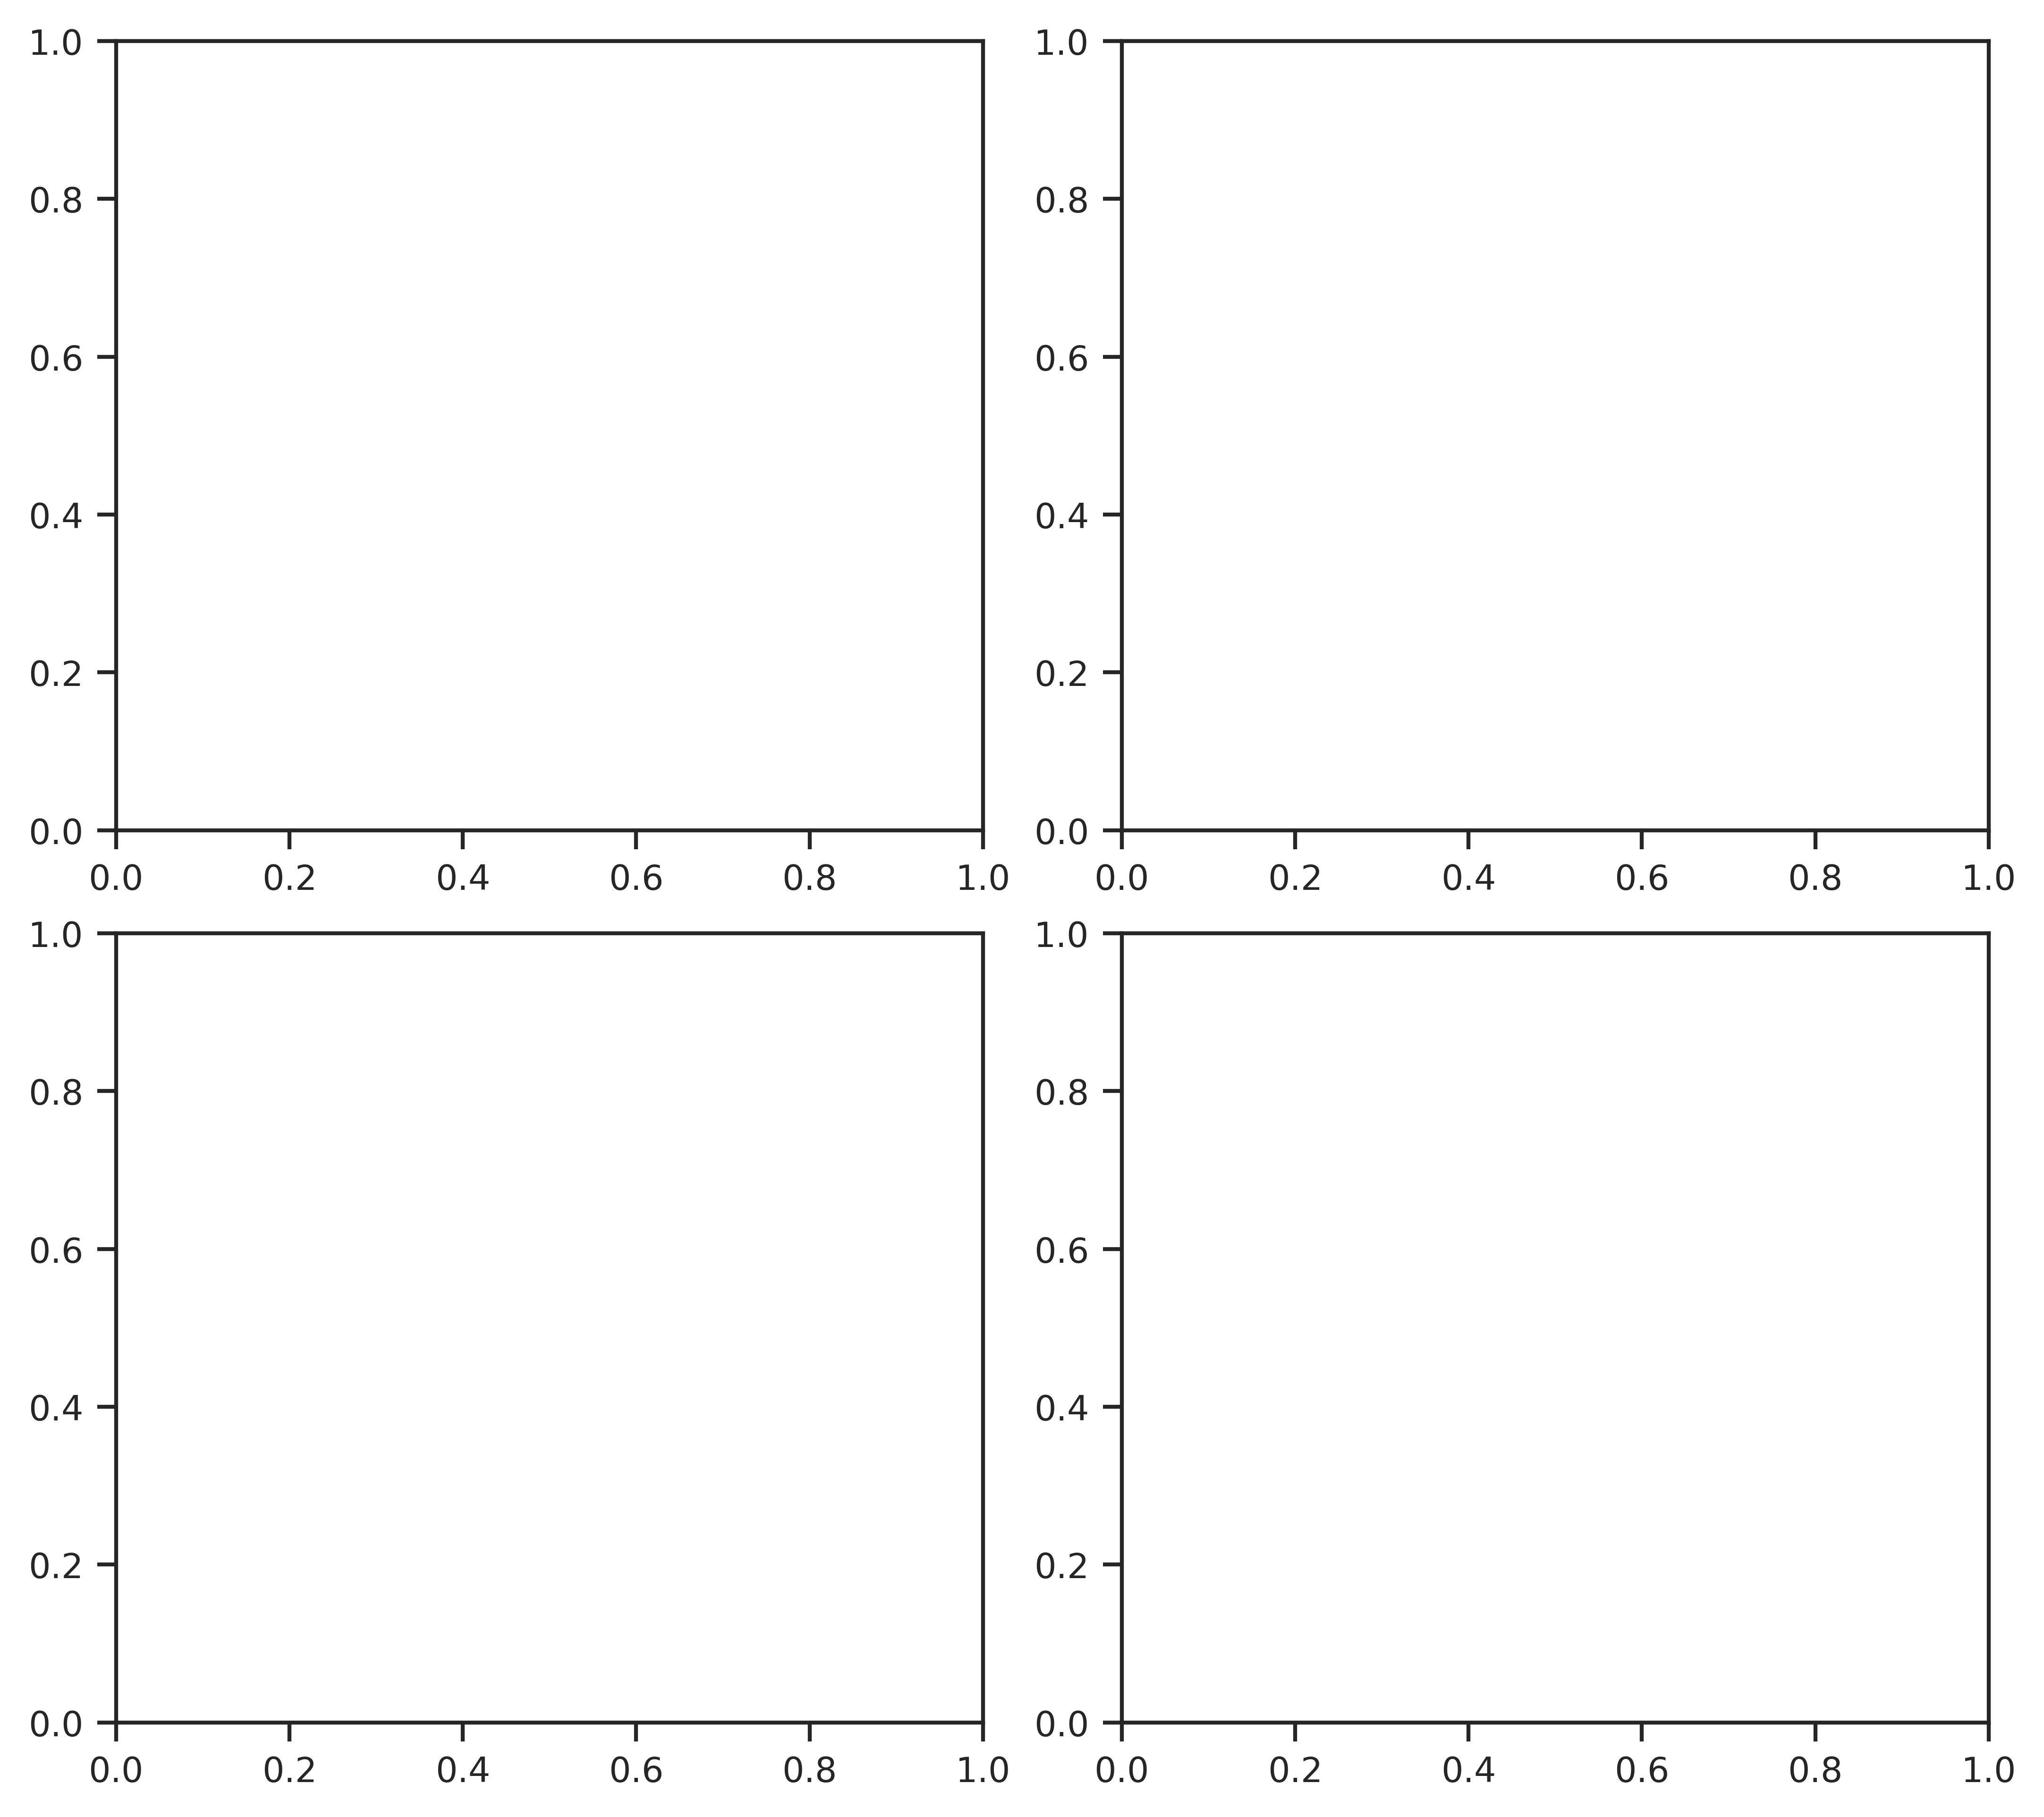

In [11]:
# Plot confusion mats
sns.set_context("paper")
sns.set_style('ticks')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
matplotlib.rcParams.update(new_rc_params)

lin_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_dset = np.array(dataset_i)[np.array(exp_i) == 'Linear']
lstmc_dset = np.array(dataset_i)[np.array(exp_i) == 'LSTM-C']

dset_order = ['Health', 'SleepAccel']
dsets = ['amazfit', 'sleepaccel']
# dset_order = ['TBI', 'DREAMT']
# dsets = ['tbi', 'dreamt']
ss_label_names = ['Wake', 'Light', 'Deep', 'REM']
ss_label_order = ['wake', 'light', 'deep', 'rem']
ss_label_map = {
    'deep': 0,
    'light': 1,
    'rem': 2,
    'wake': 3,
    'missing': -9,
}

lin_dict = {
    'title': 'Linear',
    'preds': lin_preds,
    'targets': lin_targets,
    'dset': lin_dset,
}
lstmc_dict = {
    'title': 'LSTM-C',
    'preds': lstmc_preds,
    'targets': lstmc_targets,
    'dset': lstmc_dset,
}
models = [lin_dict, lstmc_dict]

fig, axes_2d = plt.subplots(2,2, dpi=600, figsize=(7.1,6.3),layout='constrained')
for m, model in enumerate(models):
    axes = axes_2d[:,m].ravel()
    for i, dset in enumerate(dsets):
        preds = model['preds'][model['dset']==dset]
        preds = np.concatenate(list(preds))
        targets = model['targets'][model['dset']==dset]
        targets = np.concatenate(list(targets))


        # Epoch-by-epoch confusion matrix
        # Switch label orders 
        idx_dict = {}
        for place, tag in enumerate(ss_label_order):
            idx_dict[place] = (
                targets == ss_label_map[tag],
                preds == ss_label_map[tag],
            )
        for place, (label_idx, pred_idx) in idx_dict.items():
            targets[label_idx] = place
            preds[pred_idx] = place

        
        ## Confusion Matrix
        cm_abs = confusion_matrix(targets, preds, normalize=None)
        cm_norm = cm_abs/cm_abs.sum(axis=1, keepdims=True)
        # Create combined annotation matrix
        annot = np.empty_like(cm_abs).astype(str)
        for r in range(cm_abs.shape[0]):
            for c in range(cm_abs.shape[1]):
                annot[r, c] = f"{cm_norm[r, c]*100:.1f}%\n{cm_abs[r, c]}"
        ax = sns.heatmap(
            cm_norm, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, ax=axes[i],
            square=True, cbar=False, #linewidths=0.2, linecolor='black', clip_on=False,
            xticklabels=ss_label_names, yticklabels=ss_label_names,# annot_kws={'fontsize':7}
        )
        for _, spine in ax.spines.items():
            spine.set_visible(True)

        ax.tick_params(rotation = 45)
        ax.set_ylabel('Observed')
        for label in ax.get_yticklabels():
            label.set_verticalalignment('center')
        ax.set_xlabel('Predicted')
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('center')

        if m == 0:
            sec = axes[i].secondary_yaxis(location=-0.4)
            sec.set_ylabel(f'{dset_order[i]}, N={sum(model['dset']==dset)}', fontweight='bold')
            sec.set_yticks([],[])
        
        ax.set_title(f'{model['title']}, F1={round(f1_score(targets,preds,average='macro'),2)}')
plt.savefig('/oak/stanford/groups/mignot/projects/actigraphy_fm/plots/accelerest_figures/svg_test.svg', format='svg')
plt.show()



ValueError: need at least one array to concatenate

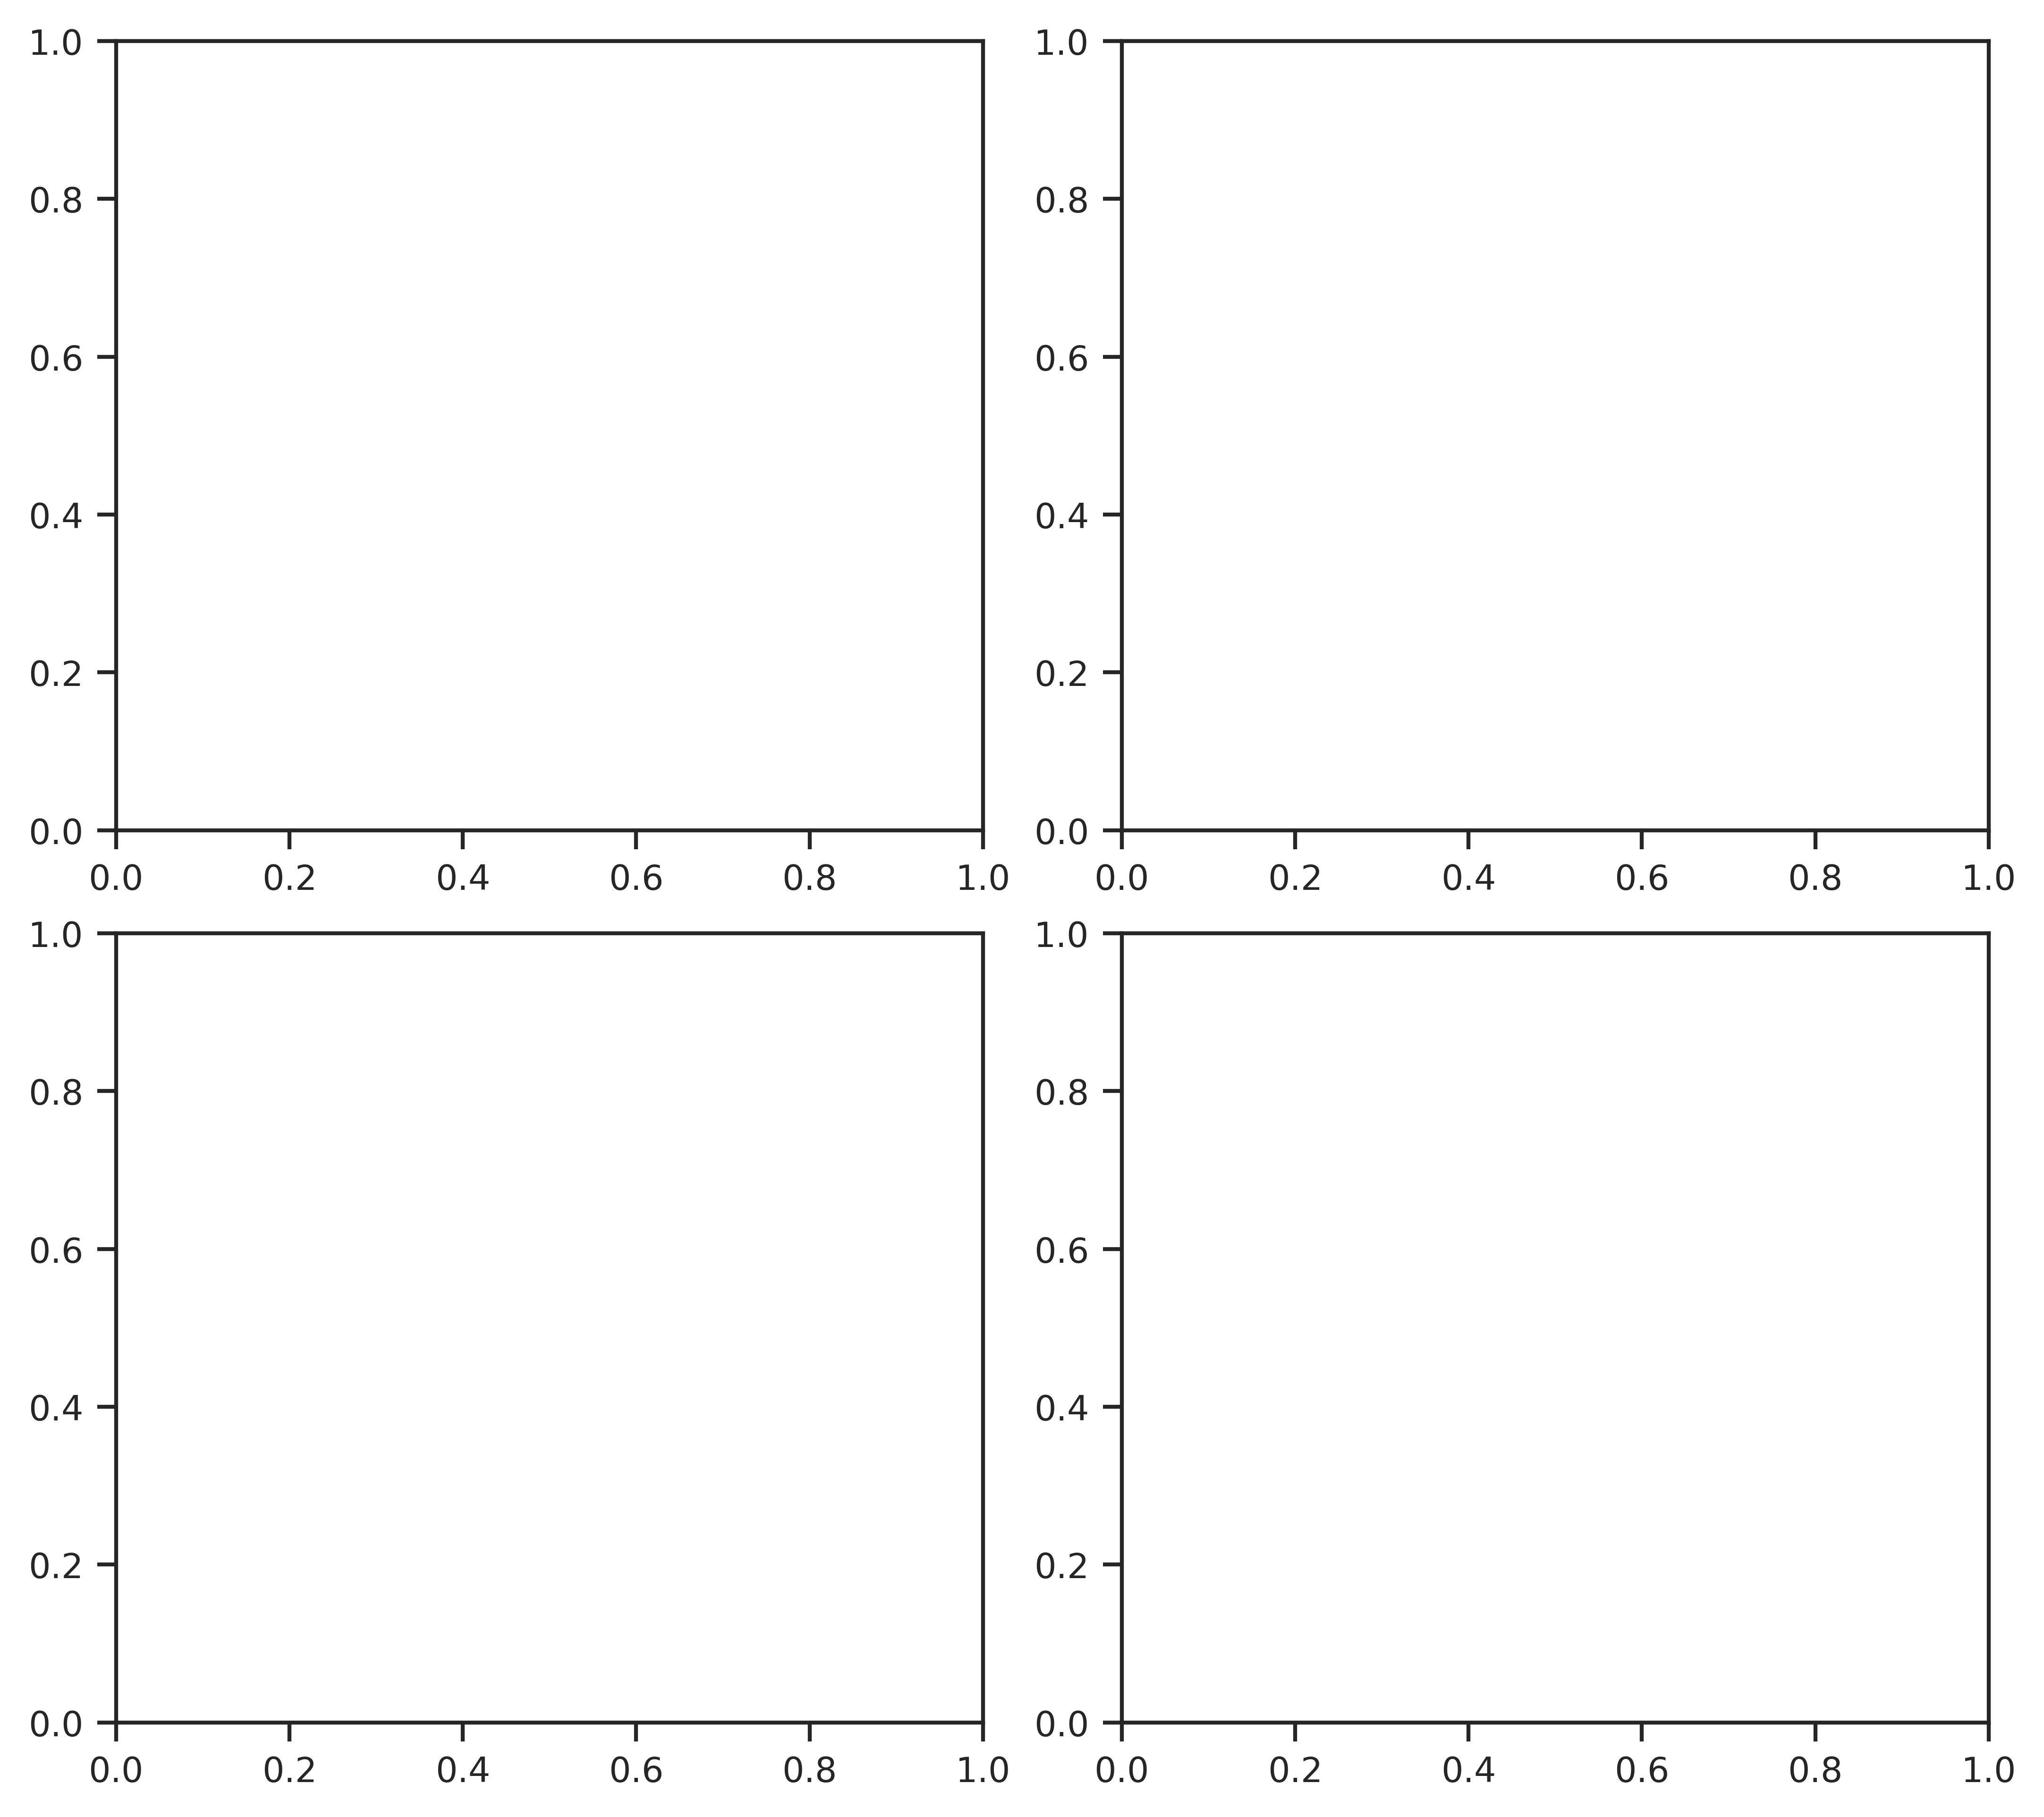

In [12]:
# Plot REM-NREM confusion mats
sns.set_context("paper")
sns.set_style('ticks')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

lin_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_preds = np.array(preds_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'Linear']
lstmc_targets = np.array(targets_all, dtype='O')[np.array(exp_i) == 'LSTM-C']

lin_dset = np.array(dataset_i)[np.array(exp_i) == 'Linear']
lin_dset[lin_dset == 'newcastle_left'] = 'newcastle'
lin_dset[lin_dset == 'newcastle_right'] = 'newcastle'
lstmc_dset = np.array(dataset_i)[np.array(exp_i) == 'LSTM-C']
lstmc_dset[lstmc_dset == 'newcastle_left'] = 'newcastle'
lstmc_dset[lstmc_dset == 'newcastle_right'] = 'newcastle'

dset_order = ['Health', 'SleepAccel']
dsets = ['amazfit', 'sleepaccel']
# dset_order = ['DREAMT', 'TBI']
# dsets = ['dreamt', 'tbi']
# dset_order = ['Newcastle', 'STAGES']
# dsets = ['newcastle', 'stages']

ss_label_names = ['Wake', 'NREM', 'REM']
rem_nrem_label_map = {
    'NREM': 0,
    'REM': 1,
    'Wake': 2,
    'missing': -9,
}

lin_dict = {
    'title': 'Linear',
    'preds': lin_preds,
    'targets': lin_targets,
    'dset': lin_dset,
}
lstmc_dict = {
    'title': 'LSTM-C',
    'preds': lstmc_preds,
    'targets': lstmc_targets,
    'dset': lstmc_dset,
}
models = [lin_dict, lstmc_dict]
fig, axes_2d = plt.subplots(2,2, dpi=600, figsize=(7.1,6.3),layout='constrained')
for m, model in enumerate(models):
    axes = axes_2d[:,m].ravel()
    for i, dset in enumerate(dsets):
        preds = model['preds'][model['dset']==dset]
        preds = np.concatenate(list(preds))
        preds[preds==1] = 0
        preds[preds==2] = 1
        preds[preds==3] = 2
        targets = model['targets'][model['dset']==dset]
        targets = np.concatenate(list(targets))
        targets[targets==1] = 0
        targets[targets==2] = 1
        targets[targets==3] = 2

        # Epoch-by-epoch confusion matrix
        # Switch label orders 
        idx_dict = {}
        for place, tag in enumerate(ss_label_names):
            idx_dict[place] = (
                targets == rem_nrem_label_map[tag],
                preds == rem_nrem_label_map[tag],
            )
        for place, (label_idx, pred_idx) in idx_dict.items():
            targets[label_idx] = place
            preds[pred_idx] = place

        
        ## Confusion Matrix
        cm_abs = confusion_matrix(targets, preds, normalize=None)
        cm_norm = cm_abs/cm_abs.sum(axis=1, keepdims=True)
        # Create combined annotation matrix
        annot = np.empty_like(cm_abs).astype(str)
        for r in range(cm_abs.shape[0]):
            for c in range(cm_abs.shape[1]):
                annot[r, c] = f"{cm_norm[r, c]*100:.1f}%\n{cm_abs[r, c]}"
        ax = sns.heatmap(
            cm_norm, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, ax=axes[i],
            square=True, cbar=False, #linewidths=0.2, linecolor='black', clip_on=False,
            xticklabels=ss_label_names, yticklabels=ss_label_names,# annot_kws={'fontsize':7}
        )
        for _, spine in ax.spines.items():
            spine.set_visible(True)

        ax.tick_params(rotation = 45)
        ax.set_ylabel('Observed')
        for label in ax.get_yticklabels():
            label.set_verticalalignment('center')
        ax.set_xlabel('Predicted')
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('center')

        if m == 0:
            sec = axes[i].secondary_yaxis(location=-0.4)
            sec.set_ylabel(f'{dset_order[i]}, N={sum(model['dset']==dset)}', fontweight='bold')
            sec.set_yticks([],[])
        
        ax.set_title(f'{model['title']}, F1={round(f1_score(targets,preds,average='macro'),2)}')
plt.show()


In [5]:
import statsmodels.api as sm

def _fit_ols_with_bootstrap(
    x,
    y,
    *,
    n_boot=2000,
    ci=95,
    seed=None,
    n_grid=200,
):
    """
    Fit y = intercept + slope*x using OLS and bootstrap paired observations.

    The bootstrap confidence intervals are percentile intervals. The plotted
    interval is a pointwise confidence band for the fitted mean relationship,
    not a prediction interval for individual observations.
    """
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    if x.size != y.size:
        raise ValueError("x and y must have the same length.")

    if x.size < 3:
        raise ValueError("At least three complete observations are required.")

    if np.ptp(x) == 0:
        raise ValueError(
            "Cannot estimate a regression slope because magnitude is constant."
        )

    if n_boot < 2:
        raise ValueError("n_boot must be at least 2.")

    if not 0 < ci < 100:
        raise ValueError("ci must be between 0 and 100.")

    # ------------------------------------------------------------------
    # Fit OLS to the original sample
    # ------------------------------------------------------------------
    X = sm.add_constant(x, has_constant="add")
    result = sm.OLS(y, X).fit(cov_type="HC3")

    # Values over which the fitted line and confidence band are evaluated
    x_grid = np.linspace(x.min(), x.max(), n_grid)
    X_grid = sm.add_constant(x_grid, has_constant="add")
    fitted = result.predict(X_grid)

    # ------------------------------------------------------------------
    # Paired/case bootstrap
    # ------------------------------------------------------------------
    rng = np.random.default_rng(seed)

    boot_params = np.empty((n_boot, 2), dtype=float)
    boot_fitted = np.empty((n_boot, n_grid), dtype=float)
    n_valid = 0

    for _ in range(n_boot):
        # Resample paired x/y rows with replacement
        idx = rng.integers(0, x.size, size=x.size)

        x_boot = x[idx]
        y_boot = y[idx]

        # The slope is not identifiable when a resample has only one x value.
        # This is very unlikely for normal continuous data, but can occur with
        # small or highly discrete datasets.
        if np.ptp(x_boot) == 0:
            continue

        X_boot = sm.add_constant(x_boot, has_constant="add")
        bootstrap_result = sm.OLS(y_boot, X_boot).fit(cov_type="HC3")
        params = np.asarray(bootstrap_result.params)

        if params.shape == (2,) and np.all(np.isfinite(params)):
            boot_params[n_valid] = params
            boot_fitted[n_valid] = X_grid @ params
            n_valid += 1

    if n_valid < 2:
        raise RuntimeError(
            "Fewer than two valid bootstrap resamples were obtained."
        )

    boot_params = boot_params[:n_valid]
    boot_fitted = boot_fitted[:n_valid]

    # ------------------------------------------------------------------
    # Percentile bootstrap intervals
    # ------------------------------------------------------------------
    tail = (100.0 - ci) / 2.0
    percentiles = [tail, 100.0 - tail]

    # Shape: (2 interval bounds, 2 coefficients)
    bootstrap_coefficient_ci = np.percentile(
        boot_params,
        percentiles,
        axis=0,
    )

    # Shape: (2 interval bounds, n_grid positions)
    bootstrap_line_ci = np.percentile(
        boot_fitted,
        percentiles,
        axis=0,
    )

    # Conventional model-based OLS confidence intervals, retained separately
    ols_coefficient_ci = np.asarray(
        result.conf_int(alpha=1.0 - ci / 100.0)
    )

    fit_info = {
        # Full statsmodels RegressionResults object
        "result": result,

        # Sample information
        "n": int(x.size),
        "n_boot_requested": int(n_boot),
        "n_boot_valid": int(n_valid),
        "ci": float(ci),

        # Point estimates
        "intercept": float(result.params[0]),
        "slope": float(result.params[1]),

        # Conventional OLS standard errors and p-values
        "intercept_se": float(result.bse[0]),
        "slope_se": float(result.bse[1]),
        "intercept_pvalue": float(result.pvalues[0]),
        "slope_pvalue": float(result.pvalues[1]),

        # Model fit
        "r_squared": float(result.rsquared),
        "adjusted_r_squared": float(result.rsquared_adj),
        "f_pvalue": float(result.f_pvalue),

        # Conventional model-based confidence intervals
        "ols_ci": {
            "intercept": tuple(
                map(float, ols_coefficient_ci[0])
            ),
            "slope": tuple(
                map(float, ols_coefficient_ci[1])
            ),
        },

        # Bootstrap standard errors
        "bootstrap_se": {
            "intercept": float(
                np.std(boot_params[:, 0], ddof=1)
            ),
            "slope": float(
                np.std(boot_params[:, 1], ddof=1)
            ),
        },

        # Percentile-bootstrap coefficient confidence intervals
        "bootstrap_ci": {
            "intercept": tuple(
                map(float, bootstrap_coefficient_ci[:, 0])
            ),
            "slope": tuple(
                map(float, bootstrap_coefficient_ci[:, 1])
            ),
        },

        # Raw bootstrap coefficient estimates, useful for diagnostics
        "bootstrap_parameters": boot_params,

        # Values needed for plotting
        "x_grid": x_grid,
        "fitted": fitted,
        "fitted_ci_lower": bootstrap_line_ci[0],
        "fitted_ci_upper": bootstrap_line_ci[1],
    }

    return fit_info

In [38]:
def reg_plot(x, y, ax):

    fit_info = _fit_ols_with_bootstrap(
        x,
        y,
        n_boot=100,
        ci=95,
        seed=42,
    )

    # print(fit_info["slope"], fit_info["intercept"])
    # print(fit_info["bootstrap_ci"])
    # print(fit_info["ols_ci"])
    # print(fit_info["slope_pvalue"])
    # print(fit_info["r_squared"])
    # print(fit_info["adjusted_r_squared"])
    
    ax.plot(
        fit_info["x_grid"],
        fit_info["fitted"],
        color="gray",
        lw=1,
        zorder=3,
    )

    ax.fill_between(
        fit_info["x_grid"],
        fit_info["fitted_ci_lower"],
        fit_info["fitted_ci_upper"],
        color="gray",
        alpha=0.2,
        linewidth=0,
        zorder=1,
    )
    slope = round(fit_info["slope"],2)
    slope_ci_up = round(fit_info["ols_ci"]["slope"][0],2)
    slope_ci_low = round(fit_info["ols_ci"]["slope"][1],2)
    # pval = round(fit_info["slope_pvalue"], 4)
    pval = (
        "<0.001"
        if fit_info["slope_pvalue"] < 0.001
        else f"{fit_info["slope_pvalue"]:.3f}"
    )
    r2 = round(fit_info["r_squared"],2) 

    ax.annotate(
        f'slope: {slope}, 95% CI: [{slope_ci_up},{slope_ci_low}]\np: {pval}, $r^2$: {r2}',
        xy=(0.95, 0.9), xycoords='axes fraction',
        xytext=(0, 0), textcoords='offset fontsize',#fontweight='bold',
        fontsize='medium', verticalalignment='center', horizontalalignment='right',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    return ax

In [ ]:
def bland_altman(magnitude, diff, ax):
    ax.scatter(x=magnitude, y=diff, s=5)

    md = np.mean(diff) # Mean of the difference
    sd = np.std(diff) # Standard deviation of the difference

    # ax.grid(axis='y', zorder=0)
    ax.axhline(md, color='black', linestyle='--',zorder=1)
    ax.axhline(0, color='gray', alpha=0.7, linestyle='-', zorder=0)

    loa_upper = md + 1.96*sd
    loa_lower = md - 1.96*sd
    ax.axhline(loa_upper, color='r', linestyle='--')
    ax.axhline(loa_lower, color='r', linestyle='--')

    # Outlier Cutoff
    # # ax.set_ylim(min(diff.min()*1.3, loa_lower*1.3), max(diff.max()*1.3, loa_upper*1.3))
    # outlier_threshold = 3.0*sd
    # upper_lim = md + outlier_threshold
    # lower_lim = md - outlier_threshold
    # ax.set_ylim(lower_lim, upper_lim)

    # # Plot outliers
    # out_up = magnitude[diff > upper_lim]
    # if len(out_up) > 0:
    #     ax.scatter(out_up, np.repeat(upper_lim-outlier_threshold*0.03, len(out_up)), marker='^',color='k', s=3)
    # out_down = magnitude[diff < lower_lim]
    # if len(out_down) > 0:
    #     ax.scatter(out_down, np.repeat(lower_lim+outlier_threshold*0.03, len(out_down)), marker='v', color='k', s=3)

    ax.set_xlim(magnitude.min()-magnitude.max()*0.2, magnitude.max()*1.2)

    # Text placement coordinates 
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    
    def get_yfrac(loc):
        return (loc - ax.get_ylim()[0]) / y_range

    ax.annotate(
        f'Mean\n{round(md,1)}',
        xy=(1.02, get_yfrac(md)), xycoords='axes fraction', fontweight='bold',
        fontsize='medium', verticalalignment='center', horizontalalignment='left',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    ax.annotate(
        f'+1.96 SD\n{round(loa_upper,1)}',
        xy=(1.02, get_yfrac(loa_upper)), xycoords='axes fraction', fontweight='bold',
        fontsize='medium', verticalalignment='center', horizontalalignment='left',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    ax.annotate(
        f'-1.96 SD\n{round(loa_lower,1)}',
        xy=(1.02, get_yfrac(loa_lower)), xycoords='axes fraction', fontweight='bold',
        fontsize='medium', verticalalignment='center', horizontalalignment='left',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    
    return ax, [md, loa_upper, loa_lower]

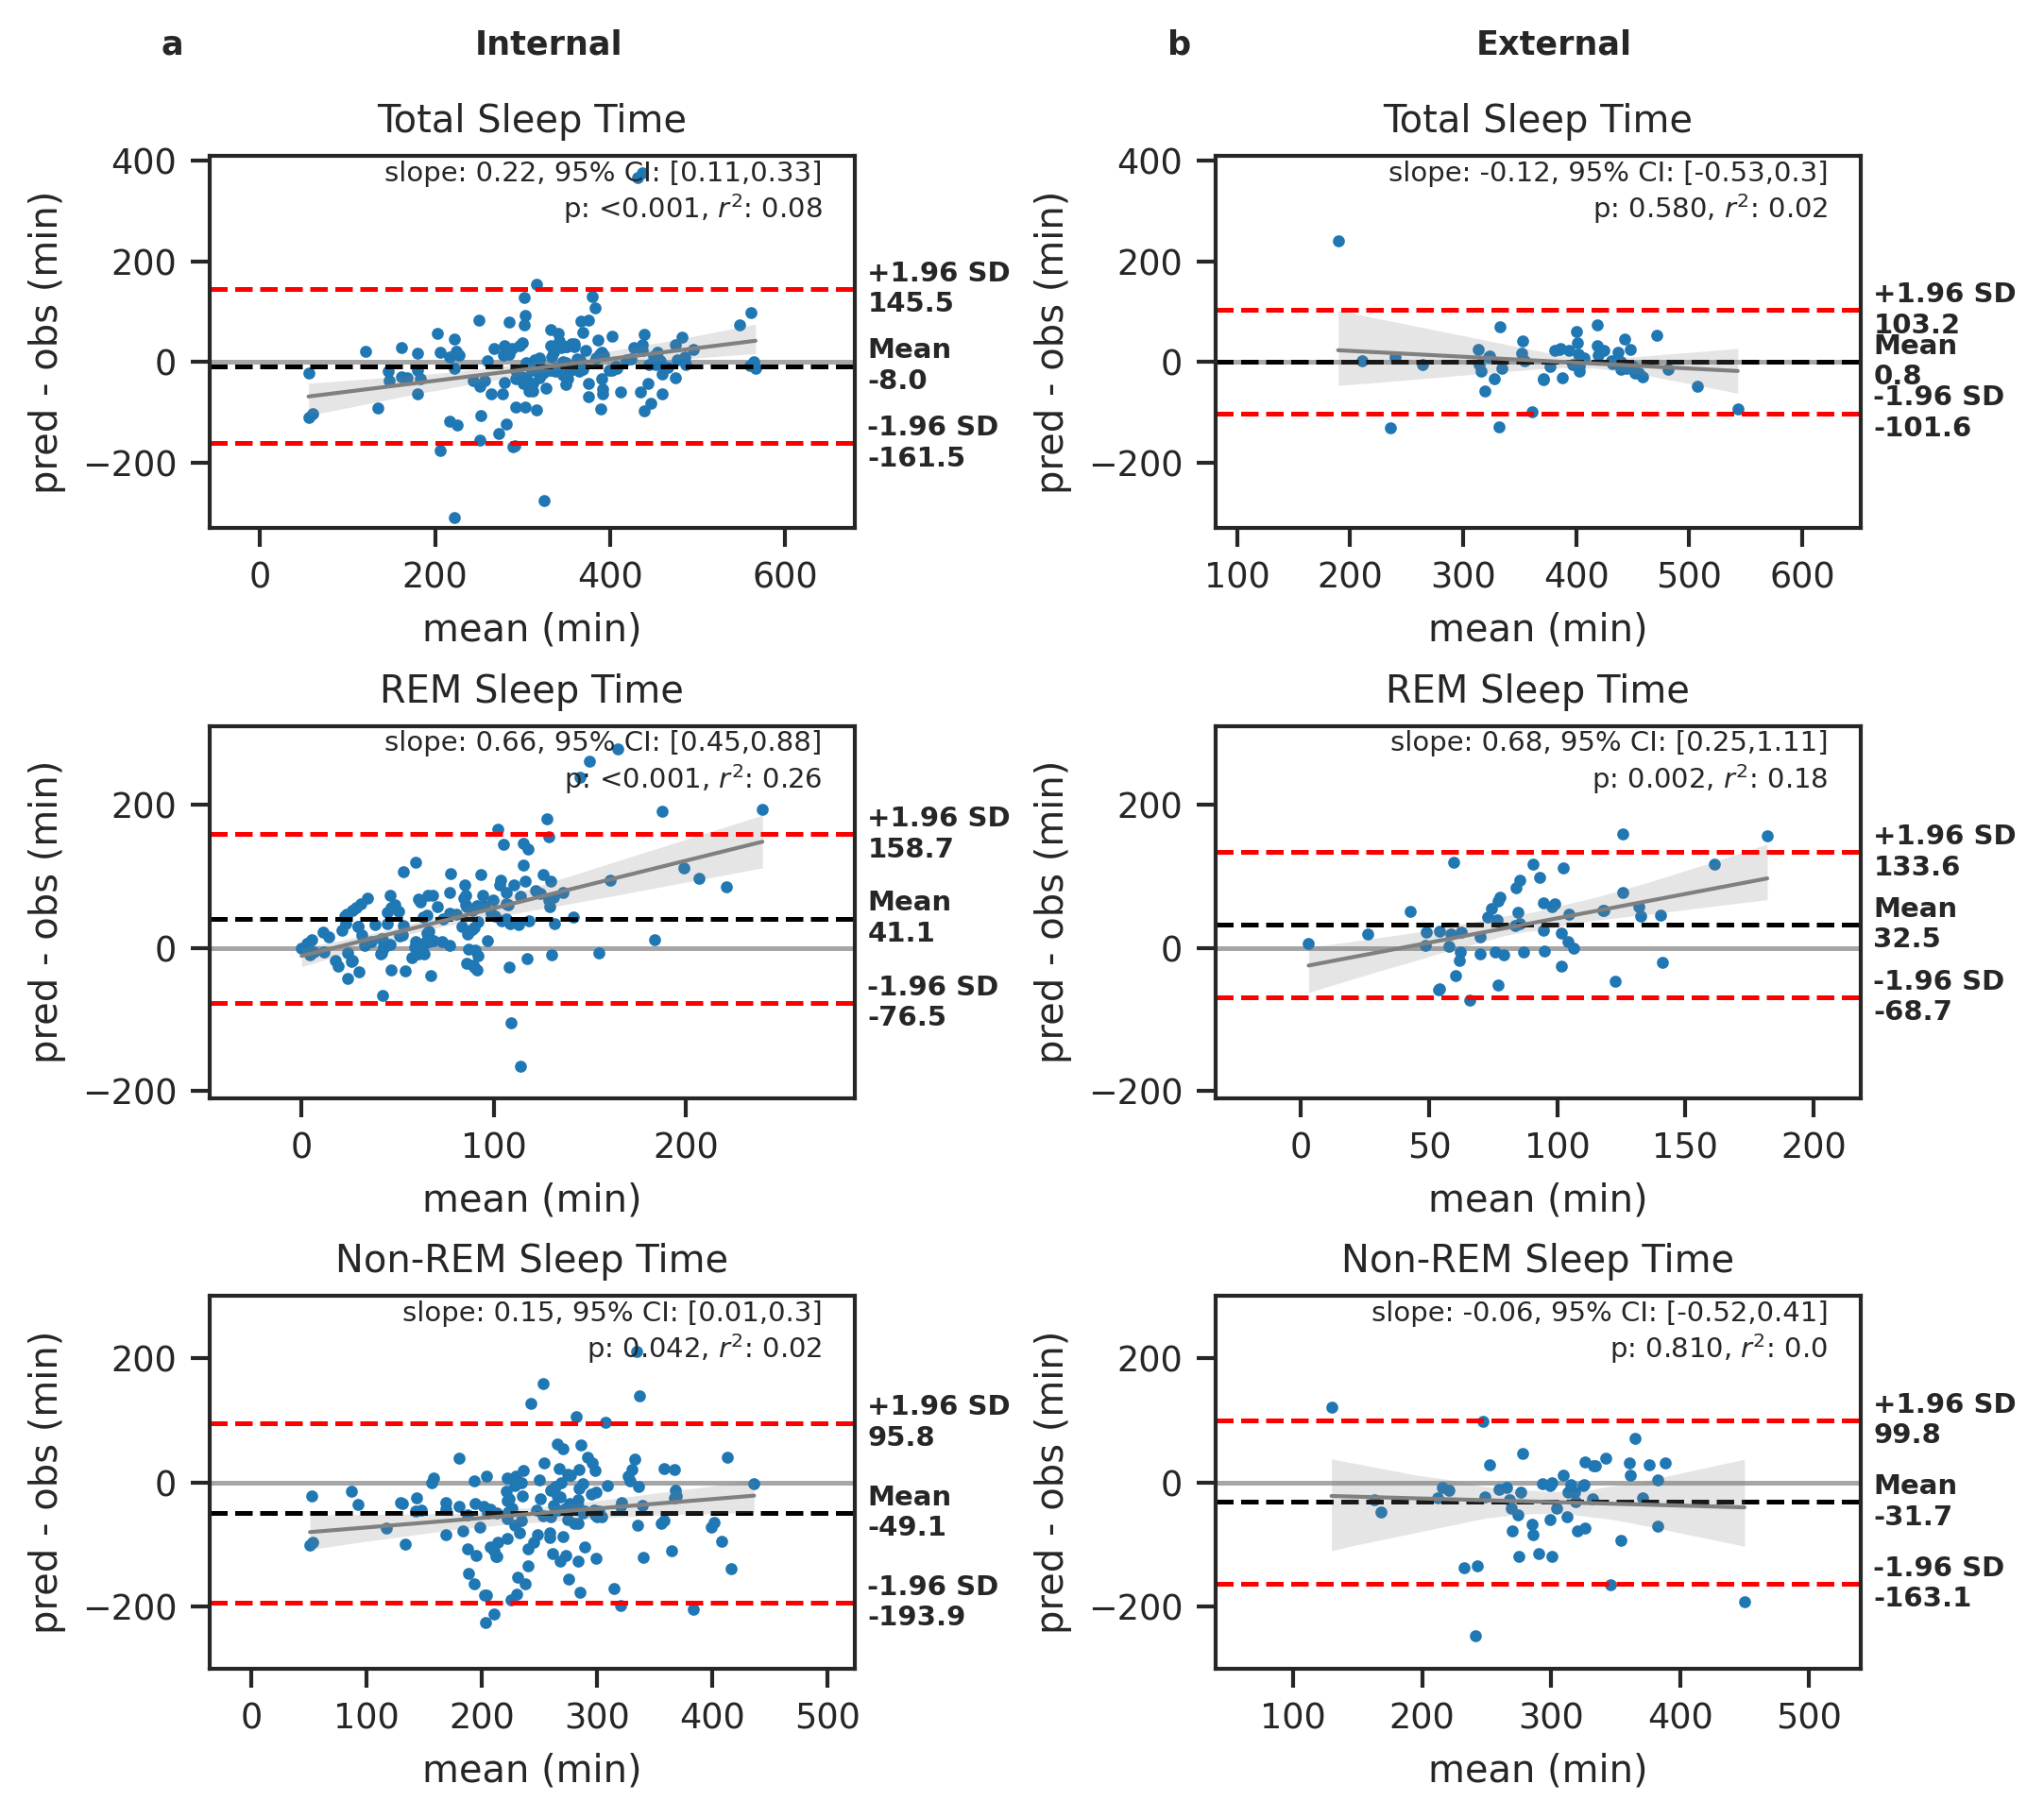

In [50]:
sns.set_context("paper")
sns.set_style('ticks')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

summary_diffs['dataset'] = dataset_i
summary_diffs['dataset'] = summary_diffs['dataset'].map(dset_map)

ba_summaries = []
errors = []
var_map = {
    'TST': 'Total Sleep Time',
    'SE': 'Sleep Efficiency',
    'REM': 'REM Sleep Time',
    'NREM': 'Non-REM Sleep Time',
    'LIGHT': 'Light Sleep Time',
    'DEEP': 'Deep Sleep Time',
    'WASO': 'Wake After Sleep Onset',
    'SOL': 'Sleep Onset Latency',
}
x_axis = 'mean' # 'obs' or 'mean'

layout = [
    ['iTST', 'eTST'],
    ['iREM', 'eREM'],
    ['iNREM','eNREM'],
    # ['SOL', 'WASO'],
    # ['Errors','Errors']
]
fig, axes = plt.subplot_mosaic(layout,figsize=(7.1,6.3), dpi=300, layout = 'constrained')
ba_summary = []
errors_ = []
for i, (var, ax) in enumerate(axes.items()):
    dset = 'Internal' if var[0] == 'i' else 'External'
    var = var[1:]
    if i <= 1:
        ax.annotate(
            f'{dset}',
            xy=(0.5, 1.3), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',fontweight='bold',
            fontsize='large', verticalalignment='bottom', horizontalalignment='center',# fontfamily='verdana',
            bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
        )
        # Add alphabetic ordering
        ax.annotate(
            f'{chr(97+i)}',
            xy=(-0.1, 1.3), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',fontweight='bold',
            fontsize='large', verticalalignment='bottom', horizontalalignment='left',# fontfamily='verdana',
            bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
        )
    diffs = summary_diffs.loc[np.array(exp_i) == dset]

    if x_axis == 'mean':
        x = summary_means.loc[np.array(exp_i) == dset]
    elif x_axis == 'obs':
        x = summary_targets.loc[np.array(exp_i) == dset]

    diff = diffs[var.lower()]
    x_ = x[var.lower()]

    ylims = [(-330, 410), (-330, 410), (-210, 310), (-210, 310), (-300, 300), (-300, 300)]
    ax.set_ylim(*ylims[i])
    ax, ba_metrics = bland_altman(x_, diff, ax)
    ax = reg_plot(x_, diff, ax)

    ax.set_title(f'{var_map[var]}')#,fontweight='bold')
    ax.set_xlabel('')
    if var == 'SE':
        ax.set_ylabel('pred - obs (%)')
        ax.set_xlabel(f'{x_axis} (%)')
    else:
        ax.set_ylabel('pred - obs (min)')
        ax.set_xlabel(f'{x_axis} (min)')
    # ax.set_yticks([0])    

    ba_metrics.append(var)
    ba_summary.append(ba_metrics)

    mae = diff.abs()
    errors_.append([mae.mean(), mae.std(), np.sqrt(np.square(diff).mean()), var])
    
ba_summaries.append(ba_summary)
errors.append(errors_)
          

In [11]:
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm

def fit_curves(x_sample, y_sample, X_grid, z, varying_sd):
    """Fit conditional bias and conditional LoA curves."""

    X_sample = sm.add_constant(
        x_sample,
        has_constant="add",
    )

    fit = sm.OLS(
        y_sample,
        X_sample,
    ).fit()

    if fit.df_resid <= 0:
        raise ValueError(
            "Insufficient residual degrees of freedom."
        )

    reg_line = np.asarray(
        fit.predict(X_grid),
        dtype=float,
    )

    residual = np.asarray(
        fit.resid,
        dtype=float,
    )

    scale_fit = None

    if varying_sd:
        # Bland-Altman two-stage model:
        #
        # E(|residual| | x) = c0 + c1*x
        #
        # If residuals are conditionally normal:
        #
        # SD(residual | x)
        #     = sqrt(pi / 2) * E(|residual| | x)

        scale_fit = sm.OLS(
            np.abs(residual),
            X_sample,
        ).fit()

        fitted_abs_residual = np.asarray(
            scale_fit.predict(X_grid),
            dtype=float,
        )

        # A linear scale model can occasionally predict a non-positive
        # value, especially near the ends of the observed x range.
        if np.any(fitted_abs_residual <= 0):
            raise ValueError(
                "The linear absolute-residual model predicts a "
                "non-positive standard deviation. Consider a log/ratio "
                "analysis or a positive-link scale model."
            )

        conditional_sd = (
            np.sqrt(np.pi / 2)
            * fitted_abs_residual
        )

    else:
        residual_sd = np.sqrt(
            np.sum(residual**2)
            / fit.df_resid
        )

        conditional_sd = np.full_like(
            x_grid,
            residual_sd,
        )

    lower_loa = reg_line - z * conditional_sd
    upper_loa = reg_line + z * conditional_sd

    return (
        reg_line,
        lower_loa,
        upper_loa,
        fit,
        scale_fit,
        conditional_sd,
    )

def regression_bland_altman(
    x,
    y,
    ax,
    loa_level=0.95,
    conf_level=0.95,
    n_boot=2000,
    seed=1234,
    varying_sd=False,
    show_bias_ci=True,
    annotate = True
):
    """
    Regression-based Bland-Altman plot with conditional limits of agreement.

    Parameters
    ----------
    x : array-like
        X-axis values. For a conventional Bland-Altman analysis, use
        (method_1 + method_2) / 2.
    y : array-like
        Pairwise differences, for example method_1 - method_2.
    ax : matplotlib.axes.Axes
        Axis on which to draw.
    loa_level : float, default=0.95
        Coverage level of the limits of agreement.
    conf_level : float, default=0.95
        Confidence level for the bootstrap uncertainty bands.
    n_boot : int, default=2000
        Number of paired-bootstrap replicates.
    seed : int, default=1234
        Random-number seed.
    varying_sd : bool, default=False
        If False, assume constant residual SD and produce parallel LoA.
        If True, model the absolute residual as a linear function of
        x, following the Bland-Altman two-stage approach.
    show_bias_ci : bool, default=True
        Plot a confidence band around the conditional bias line.

    Returns
    -------
    ax : matplotlib.axes.Axes
    metrics : dict
        Regression and scale-model statistics.
    curves : dict
        Values of the fitted curves and their pointwise confidence bounds.

    Notes
    -----
    The bootstrap intervals are pointwise confidence intervals, not
    simultaneous confidence bands over the entire x-axis.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if x.size < 5:
        raise ValueError(
            "At least five finite paired observations are required."
        )

    if np.ptp(x) == 0:
        raise ValueError(
            "The x variable has no variation."
        )

    if not 0 < loa_level < 1:
        raise ValueError("loa_level must be between 0 and 1.")

    if not 0 < conf_level < 1:
        raise ValueError("conf_level must be between 0 and 1.")

    z = norm.ppf(0.5 + loa_level / 2)

    x_grid = np.linspace(x.min(), x.max(), 250)
    X_grid = sm.add_constant(x_grid, has_constant="add")

    (
        reg_line,
        lower_loa,
        upper_loa,
        fit,
        scale_fit,
        conditional_sd,
    ) = fit_curves(x, y, X_grid, z, varying_sd)

    # ---------------------------------------------------------------
    # Paired bootstrap
    # ---------------------------------------------------------------
    rng = np.random.default_rng(seed)
    bootstrap_curves = []

    # Some varying-SD bootstrap fits may be invalid near the boundaries,
    # so allow more attempts than the requested number of replicates.
    max_attempts = max(
        2 * n_boot,
        n_boot + 100,
    )

    for _ in range(max_attempts):
        indices = rng.integers(
            low=0,
            high=x.size,
            size=x.size,
        )

        x_boot = x[indices]
        y_boot = y[indices]

        if np.ptp(x_boot) == 0:
            continue

        try:
            (
                reg_line_boot,
                lower_boot,
                upper_boot,
                fit_boot,
                scale_fit_boot,
                conditional_sd_boot,
            ) = fit_curves(x_boot, y_boot)

        except (ValueError, np.linalg.LinAlgError):
            continue

        bootstrap_curves.append(
            np.stack(
                [
                    reg_line_boot,
                    lower_boot,
                    upper_boot,
                ]
            )
        )

        if len(bootstrap_curves) == n_boot:
            break

    bootstrap_curves = np.asarray(bootstrap_curves)

    alpha = 1 - conf_level

    percentiles = [
        100 * alpha / 2,
        100 * (1 - alpha / 2),
    ]

    reg_line_ci = np.percentile(
        bootstrap_curves[:, 0, :],
        percentiles,
        axis=0,
    )

    lower_loa_ci = np.percentile(
        bootstrap_curves[:, 1, :],
        percentiles,
        axis=0,
    )

    upper_loa_ci = np.percentile(
        bootstrap_curves[:, 2, :],
        percentiles,
        axis=0,
    )

    # ---------------------------------------------------------------
    # Plot
    # ---------------------------------------------------------------
    ax = sns.scatterplot(
        x=x, y=y,s=15, ax=ax,
    )

    # ax.axhline(
    #     0,
    #     color="gray",
    #     alpha=0.7,
    #     linewidth=0.8,
    #     zorder=0,
    # )

    # Pointwise uncertainty around lower LoA.
    ax.fill_between(
        x_grid,
        lower_loa_ci[0],
        lower_loa_ci[1],
        color="red",
        alpha=0.10,
        linewidth=0,
        zorder=0,
    )

    # Pointwise uncertainty around upper LoA.
    ax.fill_between(
        x_grid,
        upper_loa_ci[0],
        upper_loa_ci[1],
        color="red",
        alpha=0.10,
        linewidth=0,
        zorder=0,
    )

    if show_bias_ci:
        ax.fill_between(
            x_grid,
            bias_ci[0],
            bias_ci[1],
            color="black",
            alpha=0.12,
            linewidth=0,
            zorder=1,
        )

    ax.plot(
        x_grid,
        reg_line,
        color="black",
        linewidth=1.2,
        zorder=2,
        label="Conditional bias",
    )

    ax.plot(
        x_grid,
        lower_loa,
        color="red",
        linestyle="--",
        linewidth=1.0,
        zorder=2,
        label=f"{loa_level:.0%} limits of agreement",
    )

    ax.plot(
        x_grid,
        upper_loa,
        color="red",
        linestyle="--",
        linewidth=1.0,
        zorder=2,
    )

    # Include the observations and the outer LoA confidence limits in
    # the displayed y-range.
    y_min = min(
        np.min(y),
        np.min(lower_loa_ci[0]),
    )

    y_max = max(
        np.max(y),
        np.max(upper_loa_ci[1]),
    )

    y_padding = (
        0.05 * (y_max - y_min)
        if y_max > y_min
        else 1.0
    )

    ax.set_ylim(
        y_min - y_padding,
        y_max + y_padding,
    )

    # ---------------------------------------------------------------
    # Statistics to return
    # ---------------------------------------------------------------
    parameter_ci = np.asarray(
        fit.conf_int(alpha = 1 - conf_level)
    )

    slope_ci = parameter_ci[1]

    metrics = {
        "intercept": float(fit.params[0]),
        "slope": float(fit.params[1]),
        "slope_ci_lower": float(slope_ci[0]),
        "slope_ci_upper": float(slope_ci[1]),
        "slope_pvalue": float(fit.pvalues[1]),
        "r_squared": float(fit.rsquared),
        "n": int(x.size),
        "valid_bootstrap_replicates": int(
            len(bootstrap_curves)
        ),
        "varying_sd": bool(varying_sd),
    }

    if varying_sd:
        scale_parameter_ci = np.asarray(
            scale_fit.conf_int(
                alpha=1 - conf_level
            )
        )

        scale_slope_ci = scale_parameter_ci[1]

        metrics.update(
            {
                "scale_intercept": float(
                    scale_fit.params[0]
                ),
                "scale_slope": float(
                    scale_fit.params[1]
                ),
                "scale_slope_ci_lower": float(
                    scale_slope_ci[0]
                ),
                "scale_slope_ci_upper": float(
                    scale_slope_ci[1]
                ),
                "scale_slope_pvalue": float(
                    scale_fit.pvalues[1]
                ),
            }
        )

    else:
        metrics["residual_sd"] = float(
            conditional_sd[0]
        )

    curves = {
        "x": x_grid,
        "bias": fitted_bias,
        "bias_ci_lower": bias_ci[0],
        "bias_ci_upper": bias_ci[1],
        "loa_lower": lower_loa,
        "loa_lower_ci_lower": lower_loa_ci[0],
        "loa_lower_ci_upper": lower_loa_ci[1],
        "loa_upper": upper_loa,
        "loa_upper_ci_lower": upper_loa_ci[0],
        "loa_upper_ci_upper": upper_loa_ci[1],
    }

    # ---------------------------------------------------------------
    # Annotation
    # ---------------------------------------------------------------
    if annotate:
        p_text = (
            "<0.001"
            if metrics["slope_pvalue"] < 0.001
            else f"{metrics["slope_pvalue"]:.3f}"
        )

        ax.text(
            0.02,
            0.98,
            (
                f"Diff = {metrics["intercept"]:.2f} {metrics["slope"]:+.3f} × x\n"
                f"Slope {ci:.0%} CI: "
                f"[{metrics["slope_ci_lower"]:.3f}, {metrics["slope_ci_upper"]:.3f}]\n"
                f"$R^2$ = {fit.rsquared:.3f}; p = {p_text}"
            ),
            transform=ax.transAxes,
            horizontalalignment="left",
            verticalalignment="top",
            fontsize="medium",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
                pad=2,
            ),
        )

    return ax, metrics, curves

In [ ]:
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm


# ---------------------------------------------------------------------
# Basic model utilities
# ---------------------------------------------------------------------

def _design_matrix(x, x_center):
    """
    Create the design matrix for:

        difference = intercept + slope * (x - x_center)
    """
    x = np.asarray(x, dtype=float)

    return np.column_stack(
        [
            np.ones_like(x),
            x - x_center,
        ]
    )


def _fit_ols(x, y, x_center, cov_type):
    """Fit an OLS model with the requested covariance estimator."""

    X = _design_matrix(x, x_center)

    return sm.OLS(y, X).fit(
        cov_type=cov_type
    )


def _fit_conditional_ba_model(
    x,
    y,
    x_grid,
    x_center,
    z_value,
    varying_sd,
    cov_type,
):
    """
    Fit the conditional bias model and calculate conditional LoA.

    Bias model
    ----------
    E(difference | x) = beta_0 + beta_1 * (x - x_center)

    Constant-SD LoA
    ----------------
    bias(x) +/- z * residual_SD

    Varying-SD LoA
    ----------------
    A linear model is fitted to the absolute residuals:

        E(|residual| | x) = gamma_0 + gamma_1 * (x - x_center)

    Under conditional normality:

        SD(residual | x)
            = sqrt(pi / 2) * E(|residual| | x)
    """

    # Bias regression
    bias_fit = _fit_ols(
        x=x,
        y=y,
        x_center=x_center,
        cov_type=cov_type,
    )

    bias_grid = (
        _design_matrix(x_grid, x_center)
        @ np.asarray(bias_fit.params)
    )

    residuals = np.asarray(
        bias_fit.resid,
        dtype=float,
    )

    # Conditional residual variability
    if varying_sd:
        scale_fit = _fit_ols(
            x=x,
            y=np.abs(residuals),
            x_center=x_center,
            cov_type=cov_type,
        )

        expected_abs_residual = (
            _design_matrix(x_grid, x_center)
            @ np.asarray(scale_fit.params)
        )

        if np.any(expected_abs_residual <= 0):
            # raise ValueError
            print(
                "The absolute-residual model predicts non-positive "
                "variability over the observed range. Consider a log "
                "transformation or a positive-link scale model."
            )

        conditional_sd = (
            np.sqrt(np.pi / 2.0)
            * expected_abs_residual
        )

    else:
        scale_fit = None

        residual_sd = np.sqrt(
            np.sum(residuals**2)
            / bias_fit.df_resid
        )

        conditional_sd = np.full_like(
            x_grid,
            residual_sd,
            dtype=float,
        )

    return {
        "bias_fit": bias_fit,
        "scale_fit": scale_fit,
        "bias": bias_grid,
        "conditional_sd": conditional_sd,
        "loa_lower": bias_grid - z_value * conditional_sd,
        "loa_upper": bias_grid + z_value * conditional_sd,
    }


# ---------------------------------------------------------------------
# Bootstrap utilities
# ---------------------------------------------------------------------

def _quantile_interval(samples, confidence_level):
    """
    Calculate a percentile interval along bootstrap axis 0.

    Works for:
      * one-dimensional parameter samples;
      * arrays of curves with shape (n_boot, n_grid);
      * arrays of parameter vectors with shape (n_boot, n_parameters).
    """

    alpha = 1.0 - confidence_level

    lower, upper = np.quantile(
        samples,
        [
            alpha / 2.0,
            1.0 - alpha / 2.0,
        ],
        axis=0,
    )

    return lower, upper


def _nonstudentized_interval(
    estimate,
    bootstrap_estimates,
    confidence_level,
    method,
):
    """
    Calculate percentile or basic bootstrap intervals.

    This is used for the scale-model parameters and residual SD, for
    which the current implementation does not calculate a fully
    studentized two-stage bootstrap statistic.
    """

    percentile_lower, percentile_upper = _quantile_interval(
        bootstrap_estimates,
        confidence_level,
    )

    if method == "percentile":
        return percentile_lower, percentile_upper

    if method == "basic":
        return (
            2.0 * estimate - percentile_upper,
            2.0 * estimate - percentile_lower,
        )

    raise ValueError(
        "method must be 'percentile' or 'basic'."
    )


def _bootstrap_case_fits(
    x,
    y,
    x_grid,
    x_center,
    z_value,
    varying_sd,
    cov_type,
    n_boot,
    rng,
):
    """
    Perform paired case bootstrap resampling.

    Each bootstrap replicate resamples complete (x, y) pairs, refits
    the bias and scale models, and recalculates the conditional LoA.
    """

    bias_parameters = []
    bias_standard_errors = []

    bias_curves = []
    lower_loa_curves = []
    upper_loa_curves = []

    scale_parameters = []
    residual_sd_values = []

    # Extra attempts are allowed because some resamples can be singular,
    # particularly when the sample is small or varying_sd=True.
    max_attempts = max(
        n_boot + 100,
        2 * n_boot,
    )

    for _ in range(max_attempts):
        indices = rng.integers(
            low=0,
            high=x.size,
            size=x.size,
        )

        x_boot = x[indices]
        y_boot = y[indices]

        # OLS cannot estimate a slope when all resampled x values
        # are identical.
        if np.ptp(x_boot) == 0:
            continue

        try:
            fit = _fit_conditional_ba_model(
                x=x_boot,
                y=y_boot,
                x_grid=x_grid,
                x_center=x_center,
                z_value=z_value,
                varying_sd=varying_sd,
                cov_type=cov_type,
            )

        except (ValueError, np.linalg.LinAlgError):
            continue

        parameters = np.asarray(
            fit["bias_fit"].params,
            dtype=float,
        )

        standard_errors = np.asarray(
            fit["bias_fit"].bse,
            dtype=float,
        )

        valid_parameters = (
            np.all(np.isfinite(parameters))
            and np.all(np.isfinite(standard_errors))
            and np.all(standard_errors > 0)
        )

        if not valid_parameters:
            continue

        bias_parameters.append(parameters)
        bias_standard_errors.append(standard_errors)

        bias_curves.append(fit["bias"])
        lower_loa_curves.append(fit["loa_lower"])
        upper_loa_curves.append(fit["loa_upper"])

        if varying_sd:
            scale_parameters.append(
                np.asarray(
                    fit["scale_fit"].params,
                    dtype=float,
                )
            )
        else:
            residual_sd_values.append(
                float(fit["conditional_sd"][0])
            )

        if len(bias_parameters) == n_boot:
            break

    minimum_valid = min(
        n_boot,
        max(
            100,
            int(np.ceil(0.8 * n_boot)),
        ),
    )

    if len(bias_parameters) < minimum_valid:
        raise RuntimeError(
            f"Only {len(bias_parameters)} valid bootstrap fits were "
            f"obtained; at least {minimum_valid} were required."
        )

    bootstrap = {
        "bias_parameters": np.asarray(
            bias_parameters
        ),
        "bias_standard_errors": np.asarray(
            bias_standard_errors
        ),
        "bias": np.asarray(
            bias_curves
        ),
        "loa_lower": np.asarray(
            lower_loa_curves
        ),
        "loa_upper": np.asarray(
            upper_loa_curves
        ),
    }

    if varying_sd:
        bootstrap["scale_parameters"] = np.asarray(
            scale_parameters
        )
    else:
        bootstrap["residual_sd"] = np.asarray(
            residual_sd_values
        )

    return bootstrap


def _bootstrap_parameter_inference(
    estimates,
    standard_errors,
    bootstrap_estimates,
    bootstrap_standard_errors,
    confidence_level,
    ci_method,
):
    """
    Calculate bootstrap inference for the bias regression parameters.

    P-values always use a centered, studentized bootstrap-t statistic.

    Confidence intervals can use:
      * bootstrap-t;
      * percentile;
      * basic.
    """

    alpha = 1.0 - confidence_level
    parameter_names = ("intercept", "slope")

    inference = {}

    for index, parameter_name in enumerate(parameter_names):
        estimate = float(
            estimates[index]
        )

        standard_error = float(
            standard_errors[index]
        )

        boot_estimate = bootstrap_estimates[:, index]
        boot_standard_error = bootstrap_standard_errors[:, index]

        valid = (
            np.isfinite(boot_estimate)
            & np.isfinite(boot_standard_error)
            & (boot_standard_error > 0)
        )

        boot_estimate = boot_estimate[valid]
        boot_standard_error = boot_standard_error[valid]

        if (
            not np.isfinite(standard_error)
            or standard_error <= 0
        ):
            raise RuntimeError(
                f"Invalid standard error for {parameter_name}."
            )

        # Centered, studentized bootstrap statistic
        t_star = (
            (boot_estimate - estimate)
            / boot_standard_error
        )

        # Null hypothesis: parameter = 0
        t_observed = estimate / standard_error

        lower_t, upper_t = np.quantile(
            t_star,
            [
                alpha / 2.0,
                1.0 - alpha / 2.0,
            ],
        )

        # -------------------------------------------------------------
        # Confidence interval
        # -------------------------------------------------------------
        if ci_method == "bootstrap-t":
            ci_lower = (
                estimate
                - upper_t * standard_error
            )

            ci_upper = (
                estimate
                - lower_t * standard_error
            )

        elif ci_method in {"percentile", "basic"}:
            ci_lower, ci_upper = _nonstudentized_interval(
                estimate=estimate,
                bootstrap_estimates=boot_estimate,
                confidence_level=confidence_level,
                method=ci_method,
            )

        else:
            raise ValueError(
                "ci_method must be 'bootstrap-t', "
                "'percentile', or 'basic'."
            )

        # -------------------------------------------------------------
        # Equal-tailed two-sided bootstrap-t p-value
        # -------------------------------------------------------------
        denominator = t_star.size + 1

        lower_tail_probability = (
            np.count_nonzero(
                t_star <= t_observed
            )
            + 1
        ) / denominator

        upper_tail_probability = (
            np.count_nonzero(
                t_star >= t_observed
            )
            + 1
        ) / denominator

        p_value = min(
            1.0,
            2.0
            * min(
                lower_tail_probability,
                upper_tail_probability,
            ),
        )

        inference[parameter_name] = {
            "estimate": estimate,
            "bootstrap_se": float(
                np.std(
                    boot_estimate,
                    ddof=1,
                )
            ),
            "ci_lower": float(ci_lower),
            "ci_upper": float(ci_upper),
            "p_value": float(p_value),
            "n_boot": int(t_star.size),
        }

    return inference


# ---------------------------------------------------------------------
# Plotting utilities
# ---------------------------------------------------------------------

def _plot_conditional_ba(
    ax,
    x_grid,
    fit,
    intervals,
    show_bias_ci,
    show_loa_ci,
):
    """Draw the conditional bias, LoA, and uncertainty bands."""

    ax.axhline(
        0,
        color="gray",
        alpha=0.7,
        linewidth=0.8,
        zorder=0,
    )

    if show_loa_ci:
        ax.fill_between(
            x_grid,
            intervals["loa_lower"][0],
            intervals["loa_lower"][1],
            color="tab:red",
            alpha=0.12,
            linewidth=0,
            zorder=0,
        )

        ax.fill_between(
            x_grid,
            intervals["loa_upper"][0],
            intervals["loa_upper"][1],
            color="tab:red",
            alpha=0.12,
            linewidth=0,
            zorder=0,
        )

    if show_bias_ci:
        ax.fill_between(
            x_grid,
            intervals["bias"][0],
            intervals["bias"][1],
            color="black",
            alpha=0.12,
            linewidth=0,
            zorder=1,
        )

    ax.plot(
        x_grid,
        fit["bias"],
        color="black",
        linewidth=1.2,
        zorder=2,
        label="Conditional bias",
    )

    ax.plot(
        x_grid,
        fit["loa_lower"],
        color="tab:red",
        linestyle="--",
        linewidth=1.0,
        zorder=2,
        label="Limits of agreement",
    )

    ax.plot(
        x_grid,
        fit["loa_upper"],
        color="tab:red",
        linestyle="--",
        linewidth=1.0,
        zorder=2,
    )


def _format_p_value(p_value):
    """Format a p-value for a plot annotation."""

    if p_value < 0.001:
        return "<0.001"

    return f"{p_value:.3f}"


# ---------------------------------------------------------------------
# Public function
# ---------------------------------------------------------------------

def regression_bland_altman(
    magnitude,
    difference,
    ax,
    *,
    loa_level=0.95,
    confidence_level=0.95,
    n_boot=2000,
    seed=1234,
    varying_sd=False,
    ci_method="bootstrap-t",
    cov_type="HC3",
    center_x=True,
    n_grid=250,
    show_bias_ci=True,
    show_loa_ci=True,
    annotate=True,
):
    """
    Regression-based Bland-Altman plot with conditional LoA and
    bootstrap inference.

    Parameters
    ----------
    magnitude : array-like
        X-axis variable. In a conventional Bland-Altman analysis this
        is normally the pairwise mean:

            (method_1 + method_2) / 2

    difference : array-like
        Pairwise difference:

            method_1 - method_2

    ax : matplotlib.axes.Axes
        Axis on which to draw.

    loa_level : float, default=0.95
        Coverage level of the limits of agreement.

    confidence_level : float, default=0.95
        Confidence level for parameter intervals and pointwise curve
        uncertainty bands.

    n_boot : int, default=2000
        Requested number of valid paired-bootstrap replicates.

    seed : int, default=1234
        Random-number seed.

    varying_sd : bool, default=False
        False:
            use one constant residual SD.

        True:
            fit a linear model to the absolute residuals, allowing the
            LoA to widen or narrow with magnitude.

    ci_method : {"bootstrap-t", "percentile", "basic"}
        Method used for the bias-regression coefficient intervals.

        P-values always use the centered bootstrap-t statistic.

    cov_type : str, default="HC3"
        Statsmodels covariance estimator used for coefficient
        studentization.

    center_x : bool, default=True
        Center magnitude at its sample mean.

        This leaves the slope and fitted curves unchanged but makes the
        intercept represent expected bias at the average magnitude,
        rather than expected bias at magnitude zero.

    n_grid : int, default=250
        Number of grid points used to draw the curves.

    show_bias_ci : bool, default=True
        Show the pointwise confidence band around the bias curve.

    show_loa_ci : bool, default=True
        Show pointwise confidence bands around the LoA curves.

    annotate : bool, default=True
        Add slope, slope CI, and slope p-value to the plot.

    Returns
    -------
    ax : matplotlib.axes.Axes

    summary : dict
        Flat dictionary containing coefficient estimates, bootstrap
        confidence intervals, bootstrap p-values, and model details.

    curves : dict
        Fitted bias and LoA curves with their pointwise confidence limits.
    """

    # -----------------------------------------------------------------
    # Validate arguments
    # -----------------------------------------------------------------
    if not 0 < loa_level < 1:
        raise ValueError(
            "loa_level must be between 0 and 1."
        )

    if not 0 < confidence_level < 1:
        raise ValueError(
            "confidence_level must be between 0 and 1."
        )

    if n_boot < 100:
        raise ValueError(
            "n_boot must be at least 100."
        )

    if n_grid < 2:
        raise ValueError(
            "n_grid must be at least 2."
        )

    if ci_method not in {
        "bootstrap-t",
        "percentile",
        "basic",
    }:
        raise ValueError(
            "ci_method must be 'bootstrap-t', "
            "'percentile', or 'basic'."
        )

    # -----------------------------------------------------------------
    # Clean paired observations
    # -----------------------------------------------------------------
    x = np.asarray(
        magnitude,
        dtype=float,
    )

    y = np.asarray(
        difference,
        dtype=float,
    )

    if x.shape != y.shape:
        raise ValueError(
            "magnitude and difference must have the same shape."
        )

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    if x.size < 5:
        raise ValueError(
            "At least five finite paired observations are required."
        )

    if np.ptp(x) == 0:
        raise ValueError(
            "magnitude must contain more than one unique value."
        )

    # The reference value remains fixed across bootstrap replicates.
    x_center = (
        float(np.mean(x))
        if center_x
        else 0.0
    )

    x_grid = np.linspace(
        x.min(),
        x.max(),
        n_grid,
    )

    z_value = norm.ppf(
        0.5 + loa_level / 2.0
    )

    # -----------------------------------------------------------------
    # Fit original sample
    # -----------------------------------------------------------------
    fit = _fit_conditional_ba_model(
        x=x,
        y=y,
        x_grid=x_grid,
        x_center=x_center,
        z_value=z_value,
        varying_sd=varying_sd,
        cov_type=cov_type,
    )

    # -----------------------------------------------------------------
    # Bootstrap
    # -----------------------------------------------------------------
    bootstrap = _bootstrap_case_fits(
        x=x,
        y=y,
        x_grid=x_grid,
        x_center=x_center,
        z_value=z_value,
        varying_sd=varying_sd,
        cov_type=cov_type,
        n_boot=n_boot,
        rng=np.random.default_rng(seed),
    )

    # Pointwise percentile bands for the plotted curves
    intervals = {
        "bias": _quantile_interval(
            bootstrap["bias"],
            confidence_level,
        ),
        "loa_lower": _quantile_interval(
            bootstrap["loa_lower"],
            confidence_level,
        ),
        "loa_upper": _quantile_interval(
            bootstrap["loa_upper"],
            confidence_level,
        ),
    }

    # Bootstrap inference for intercept and slope
    coefficient_inference = 3(
        estimates=np.asarray(
            fit["bias_fit"].params
        ),
        standard_errors=np.asarray(
            fit["bias_fit"].bse
        ),
        bootstrap_estimates=bootstrap[
            "bias_parameters"
        ],
        bootstrap_standard_errors=bootstrap[
            "bias_standard_errors"
        ],
        confidence_level=confidence_level,
        ci_method=ci_method,
    )

    # -----------------------------------------------------------------
    # Plot
    # -----------------------------------------------------------------
    _plot_conditional_ba(
        ax=ax,
        x_grid=x_grid,
        fit=fit,
        intervals=intervals,
        show_bias_ci=show_bias_ci,
        show_loa_ci=show_loa_ci,
    )

    slope_result = coefficient_inference["slope"]

    if annotate:
        ax.text(
            0.02,
            0.98,
            (
                f"Slope = {slope_result['estimate']:.3f}\n"
                f"{confidence_level:.0%} CI: "
                f"[{slope_result['ci_lower']:.3f}, "
                f"{slope_result['ci_upper']:.3f}]\n"
                f"Bootstrap p "
                f"{_format_p_value(slope_result['p_value'])}"
            ),
            transform=ax.transAxes,
            horizontalalignment="left",
            verticalalignment="top",
            fontsize="medium",
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.75,
                "pad": 2,
            },
        )

    # -----------------------------------------------------------------
    # Flat summary dictionary
    # -----------------------------------------------------------------
    summary = {
        "n": int(x.size),
        "x_center": x_center,
        "r_squared": float(
            fit["bias_fit"].rsquared
        ),
        "varying_sd": bool(varying_sd),
        "n_boot": int(
            bootstrap["bias_parameters"].shape[0]
        ),
        "ci_method": ci_method,
        "curve_ci_method": "pointwise percentile",
        "pvalue_method": "paired case bootstrap-t",
        "cov_type": cov_type,
    }

    for parameter_name, result in coefficient_inference.items():
        summary[parameter_name] = result["estimate"]

        summary[
            f"{parameter_name}_bootstrap_se"
        ] = result["bootstrap_se"]

        summary[
            f"{parameter_name}_ci_lower"
        ] = result["ci_lower"]

        summary[
            f"{parameter_name}_ci_upper"
        ] = result["ci_upper"]

        summary[
            f"{parameter_name}_pvalue"
        ] = result["p_value"]

    # -----------------------------------------------------------------
    # Scale model or constant residual SD
    # -----------------------------------------------------------------
    if varying_sd:
        scale_estimate = np.asarray(
            fit["scale_fit"].params
        )

        # The scale model is two-stage, so use a non-studentized
        # case-bootstrap interval here.
        scale_ci_method = (
            ci_method
            if ci_method in {"percentile", "basic"}
            else "percentile"
        )

        scale_lower, scale_upper = _nonstudentized_interval(
            estimate=scale_estimate,
            bootstrap_estimates=bootstrap[
                "scale_parameters"
            ],
            confidence_level=confidence_level,
            method=scale_ci_method,
        )

        summary.update(
            {
                "scale_intercept": float(
                    scale_estimate[0]
                ),
                "scale_intercept_ci_lower": float(
                    scale_lower[0]
                ),
                "scale_intercept_ci_upper": float(
                    scale_upper[0]
                ),
                "scale_slope": float(
                    scale_estimate[1]
                ),
                "scale_slope_ci_lower": float(
                    scale_lower[1]
                ),
                "scale_slope_ci_upper": float(
                    scale_upper[1]
                ),
                "scale_ci_method": scale_ci_method,
            }
        )

    else:
        residual_sd = float(
            fit["conditional_sd"][0]
        )

        sd_ci_method = (
            ci_method
            if ci_method in {"percentile", "basic"}
            else "percentile"
        )

        sd_lower, sd_upper = _nonstudentized_interval(
            estimate=residual_sd,
            bootstrap_estimates=bootstrap[
                "residual_sd"
            ],
            confidence_level=confidence_level,
            method=sd_ci_method,
        )

        summary.update(
            {
                "residual_sd": residual_sd,
                "residual_sd_ci_lower": float(
                    sd_lower
                ),
                "residual_sd_ci_upper": float(
                    sd_upper
                ),
                "residual_sd_ci_method": sd_ci_method,
            }
        )

    # -----------------------------------------------------------------
    # Curves for optional downstream use
    # -----------------------------------------------------------------
    curves = {
        "x": x_grid,
        "bias": fit["bias"],
        "bias_ci_lower": intervals["bias"][0],
        "bias_ci_upper": intervals["bias"][1],
        "loa_lower": fit["loa_lower"],
        "loa_lower_ci_lower": intervals[
            "loa_lower"
        ][0],
        "loa_lower_ci_upper": intervals[
            "loa_lower"
        ][1],
        "loa_upper": fit["loa_upper"],
        "loa_upper_ci_lower": intervals[
            "loa_upper"
        ][0],
        "loa_upper_ci_upper": intervals[
            "loa_upper"
        ][1],
        "conditional_sd": fit["conditional_sd"],
    }

    return ax, summary, curves

The absolute-residual model predicts non-positive variability over the observed range. Consider a log transformation or a positive-link scale model.
The absolute-residual model predicts non-positive variability over the observed range. Consider a log transformation or a positive-link scale model.
The absolute-residual model predicts non-positive variability over the observed range. Consider a log transformation or a positive-link scale model.
The absolute-residual model predicts non-positive variability over the observed range. Consider a log transformation or a positive-link scale model.
The absolute-residual model predicts non-positive variability over the observed range. Consider a log transformation or a positive-link scale model.
The absolute-residual model predicts non-positive variability over the observed range. Consider a log transformation or a positive-link scale model.
The absolute-residual model predicts non-positive variability over the observed range. Consider a log tran

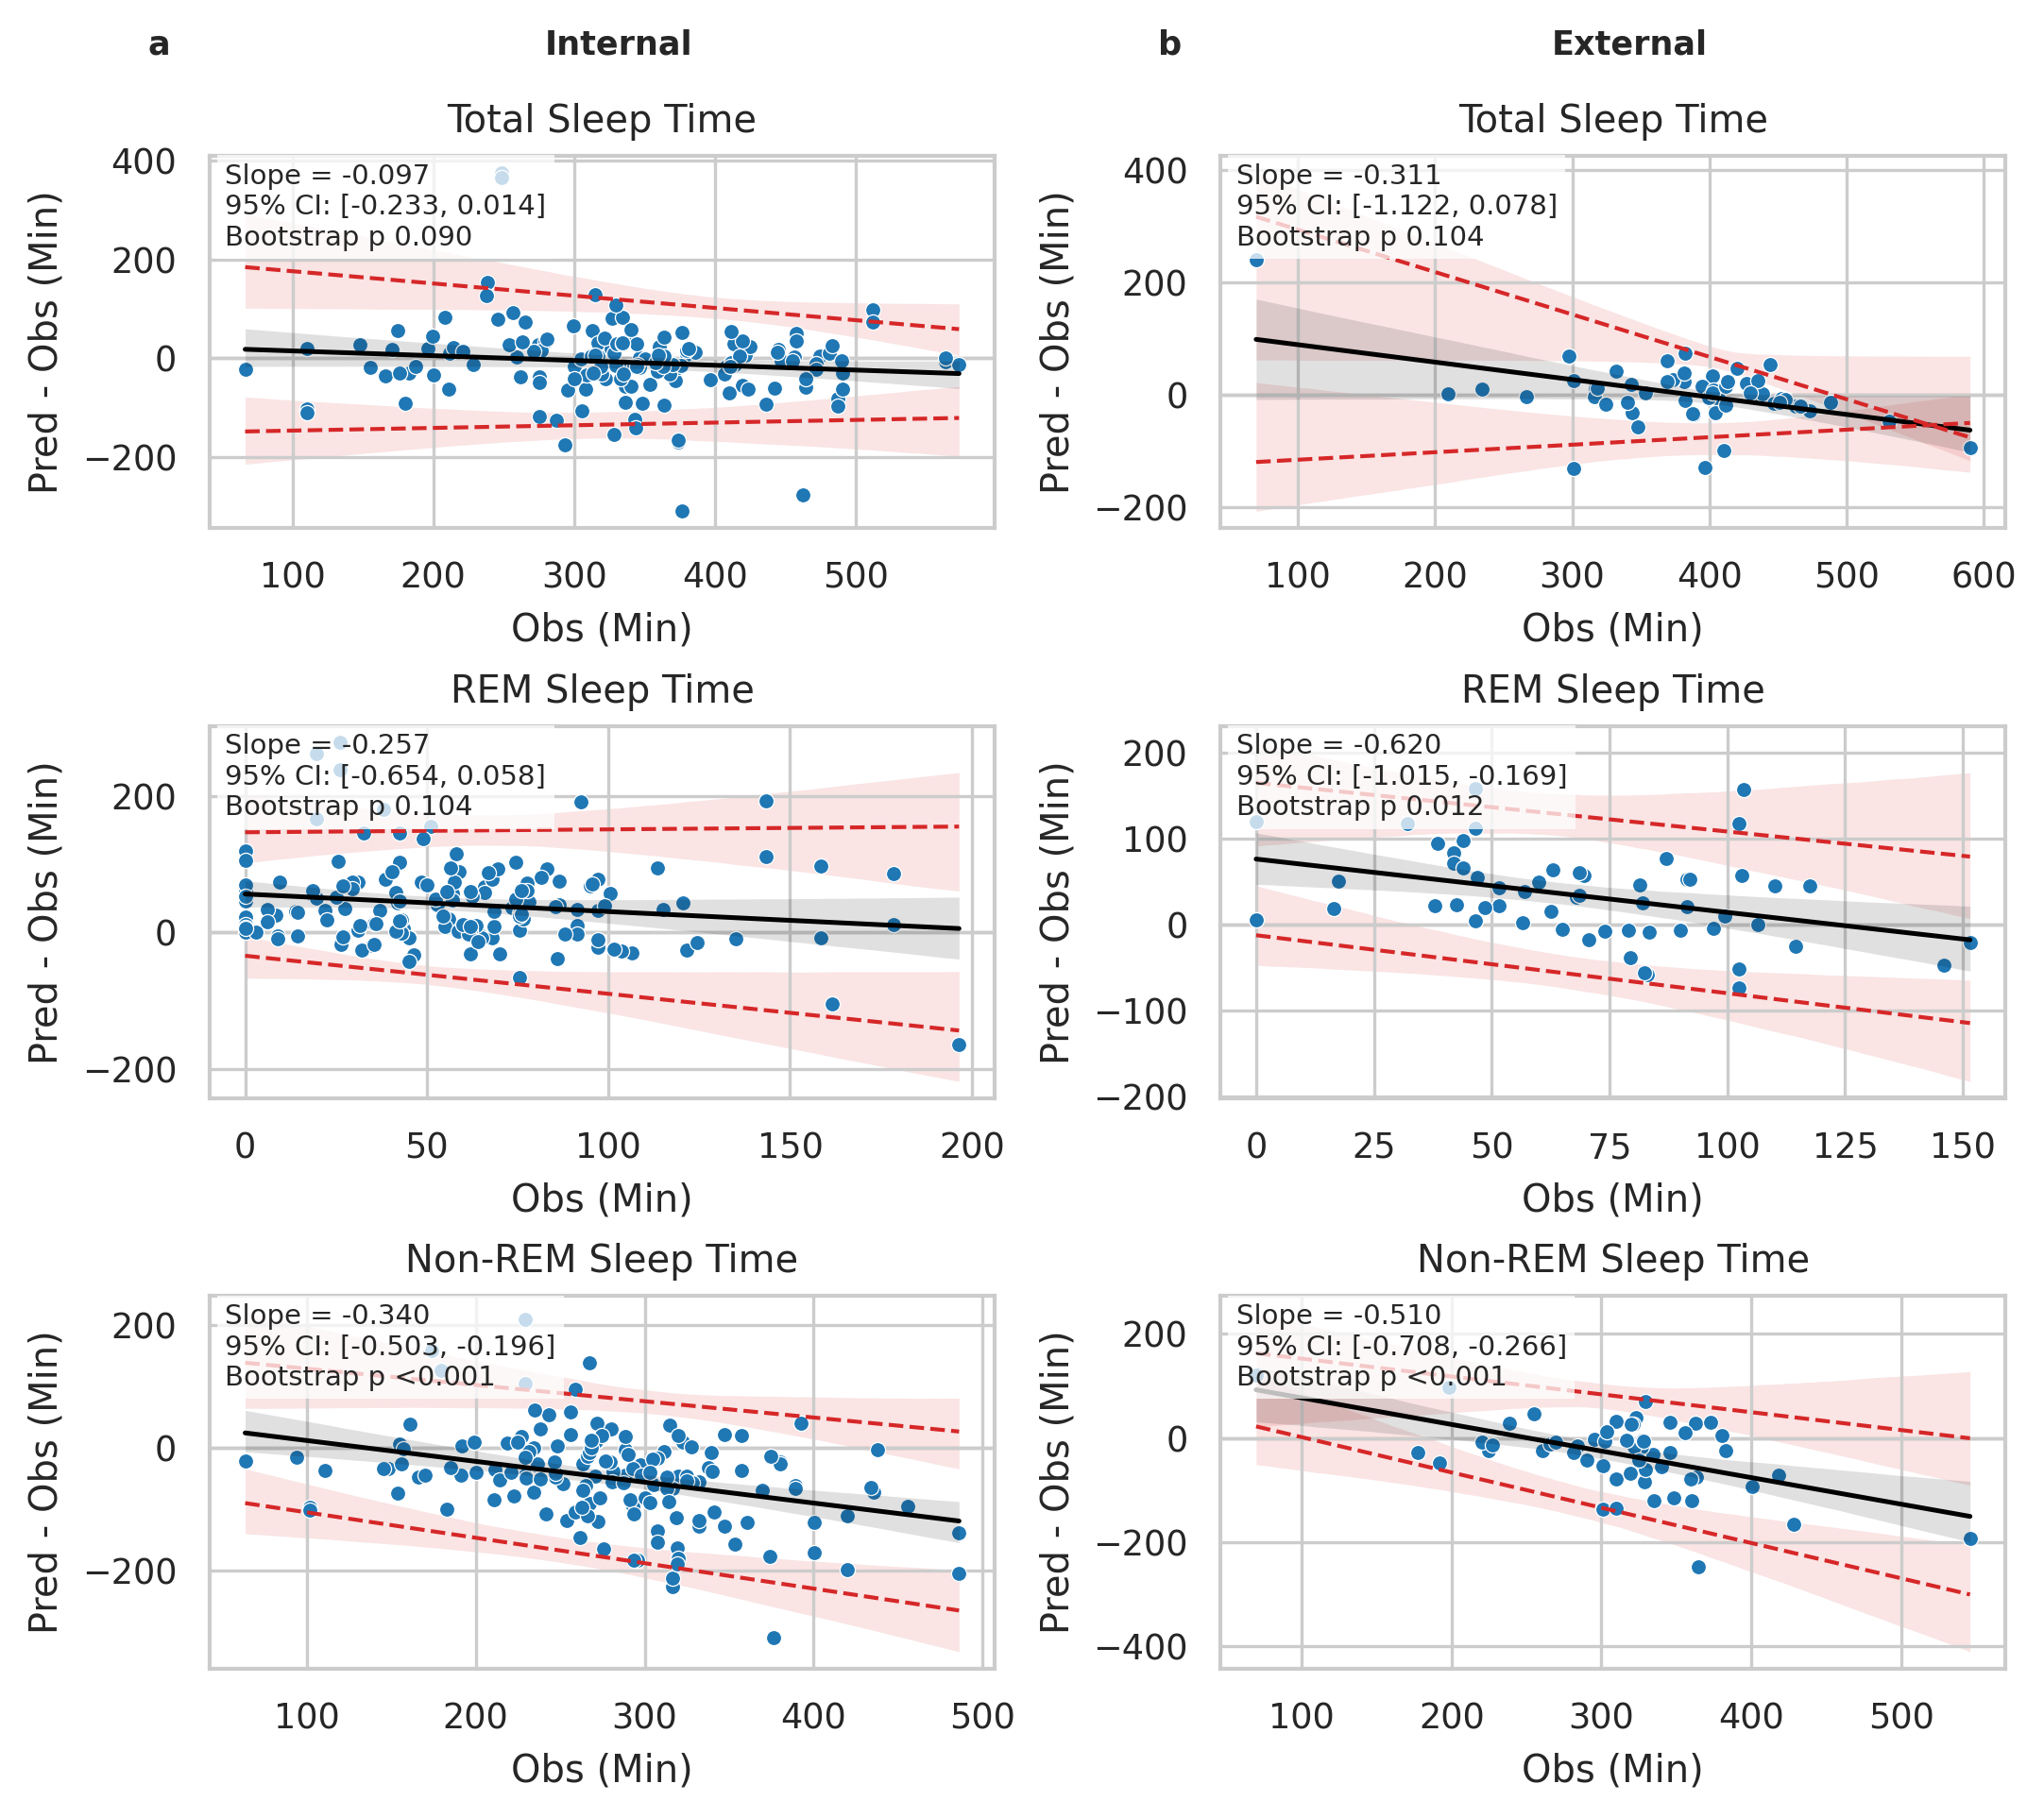

In [32]:
sns.set_context("paper")
sns.set_style('whitegrid')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

summary_diffs['dataset'] = dataset_i
summary_diffs['dataset'] = summary_diffs['dataset'].map(dset_map)

ba_summaries = []
errors = []
var_map = {
    'TST': 'Total Sleep Time',
    'SE': 'Sleep Efficiency',
    'REM': 'REM Sleep Time',
    'NREM': 'Non-REM Sleep Time',
    'LIGHT': 'Light Sleep Time',
    'DEEP': 'Deep Sleep Time',
    'WASO': 'Wake After Sleep Onset',
    'SOL': 'Sleep Onset Latency',
}

layout = [
    ['iTST', 'eTST'],
    ['iREM', 'eREM'],
    ['iNREM','eNREM'],
    # ['SOL', 'WASO'],
    # ['Errors','Errors']
]
fig, axes = plt.subplot_mosaic(layout,figsize=(7.1,6.3), dpi=300, layout = 'constrained')
ba_summary = []
errors_ = []
for i, (var, ax) in enumerate(axes.items()):
    dset = 'Internal' if var[0] == 'i' else 'External'
    var = var[1:]
    if i <= 1:
        ax.annotate(
            f'{dset}',
            xy=(0.5, 1.3), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',fontweight='bold',
            fontsize='large', verticalalignment='bottom', horizontalalignment='center',# fontfamily='verdana',
            bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
        )
        # Add alphabetic ordering
        ax.annotate(
            f'{chr(97+i)}',
            xy=(-0.1, 1.3), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',fontweight='bold',
            fontsize='large', verticalalignment='bottom', horizontalalignment='left',# fontfamily='verdana',
            bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
        )
    diffs = summary_diffs.loc[np.array(exp_i) == dset]
    means = summary_targets.loc[np.array(exp_i) == dset]

    diff = diffs[var.lower()]
    mean = means[var.lower()]

    ax = sns.scatterplot(
        x=mean,
        y=diff,
        s=15,
        ax=ax,
    )

    ax, ba_metrics, ba_curves = regression_bland_altman(
        magnitude=mean,
        difference=diff,
        ax=ax,
        loa_level=0.95,
        confidence_level=0.95,
        n_boot=4999,
        seed=1234 + i,
        varying_sd=True,
        ci_method="bootstrap-t",
        cov_type="HC3",
        center_x=True,
        show_bias_ci=True,
        show_loa_ci=True,
        annotate=True,
    )

    ba_metrics["variable"] = var
    ba_metrics["dataset"] = dset
    ba_summary.append(ba_metrics)
    
    # ax, ba_metrics = bland_altman(mean, diff, ax)#, annot_pos='left' if var == 'SE' else 'right')
    ax.set_title(f'{var_map[var]}')#,fontweight='bold')
    ax.set_xlabel('')
    if var == 'SE':
        ax.set_ylabel('Pred - Obs (%)')
        ax.set_xlabel('Obs (%)')
    else:
        ax.set_ylabel('Pred - Obs (Min)')
        ax.set_xlabel('Obs (Min)')
    # ax.set_yticks([0])    

    # ba_metrics.append(var)
    # ba_summary.append(ba_metrics)

    mae = diff.abs()
    errors_.append([mae.mean(), mae.std(), np.sqrt(np.square(diff).mean()), var])
    
ba_summaries.append(ba_summary)
errors.append(errors_)

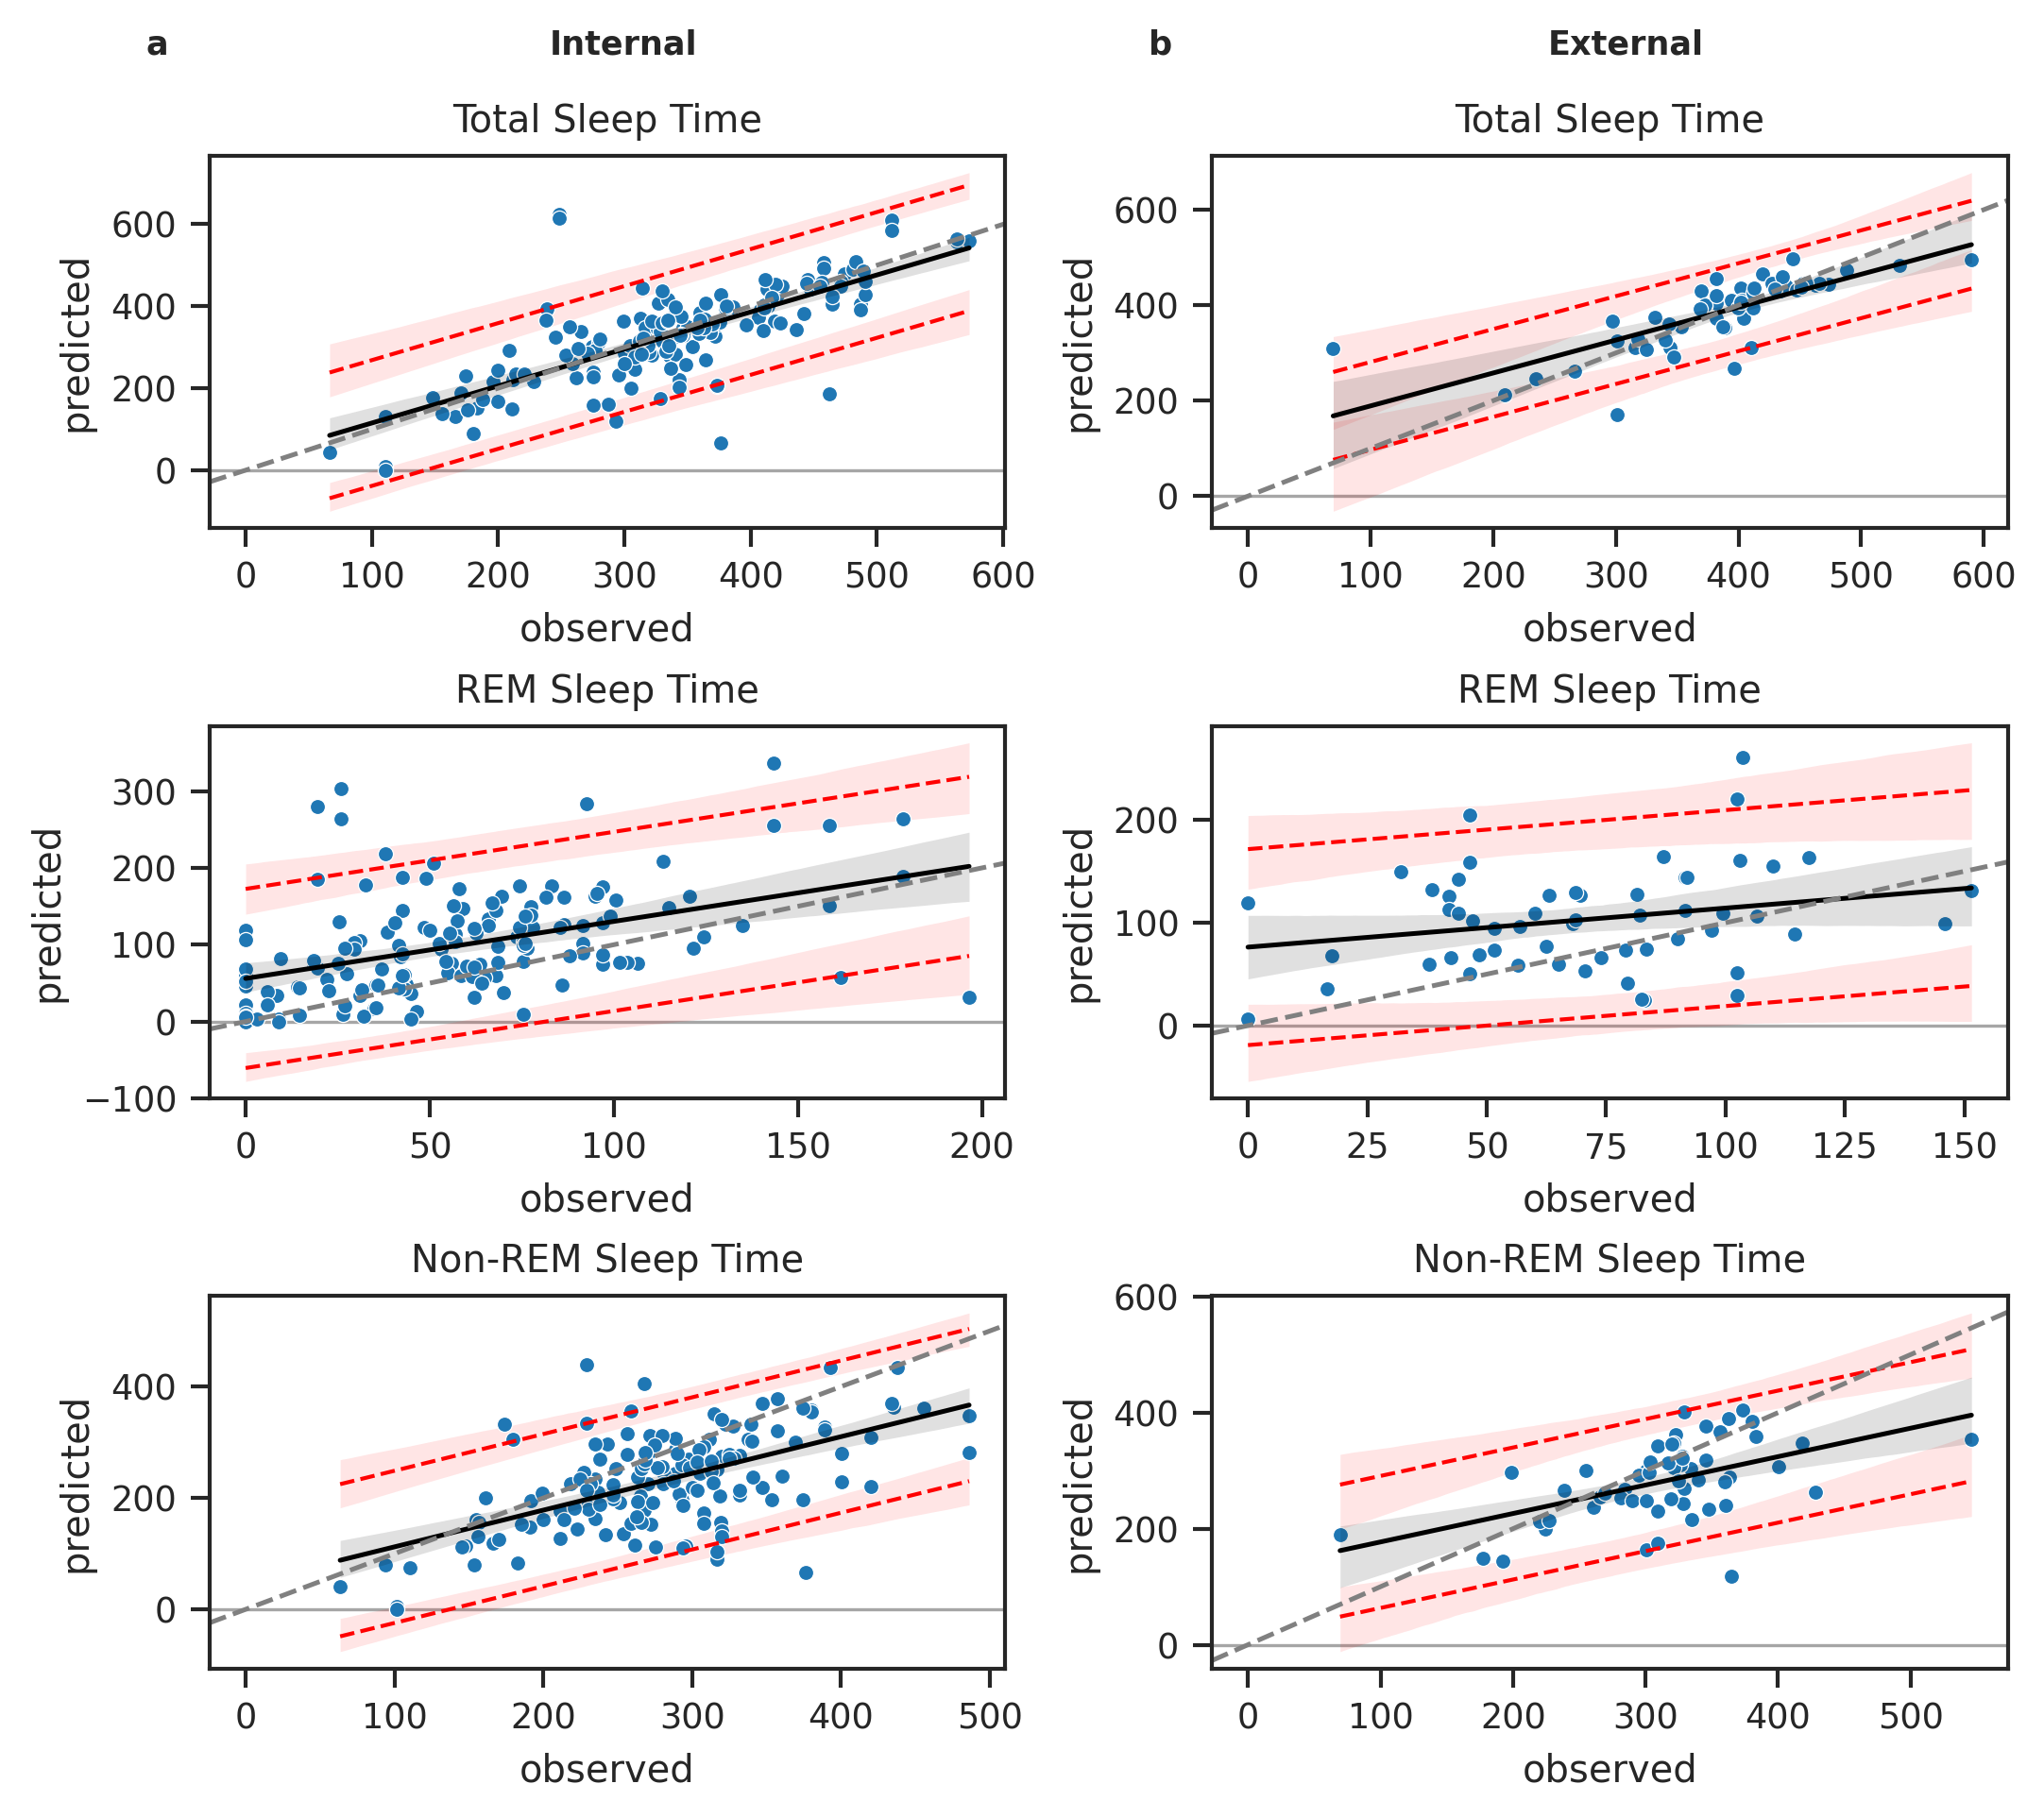

In [44]:
layout = [
    ['iTST', 'eTST'],
    ['iREM', 'eREM'],
    ['iNREM','eNREM'],
]
fig, axes = plt.subplot_mosaic(layout,figsize=(7.1,6.3), dpi=300, layout = 'constrained')
for i, (var, ax) in enumerate(axes.items()):
    exp = 'Internal' if var[0] == 'i' else 'External'
    var = var[1:]
    if i <= 1:
        ax.annotate(
            f'{exp}',
            xy=(0.5, 1.3), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',fontweight='bold',
            fontsize='large', verticalalignment='bottom', horizontalalignment='center',# fontfamily='verdana',
            bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
        )
        # Add alphabetic ordering
        ax.annotate(
            f'{chr(97+i)}',
            xy=(-0.1, 1.3), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',fontweight='bold',
            fontsize='large', verticalalignment='bottom', horizontalalignment='left',# fontfamily='verdana',
            bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
        )
    x = summary_targets.loc[np.array(exp_i) == exp, var.lower()]
    y = summary_preds.loc[np.array(exp_i) == exp, var.lower()] 

    # regression_bland_altmann(x=x, y=y, robust = True, ax = ax)
    
    ax, ba_metrics, ba_curves = regression_bland_altman(
        x=x,
        y=y,
        ax=ax,
        loa_level=0.95,
        conf_level=0.95,
        n_boot=2000,
        seed=1234,
        varying_sd=False,
    )
    ax.axline((0,0), slope=1, color = 'grey', ls = '--')
    
    ax.set_title(f'{var_map[var]}')
    ax.set_ylabel('predicted')
    ax.set_xlabel('observed')


In [19]:
ba_lin = pd.DataFrame(ba_summaries[0], columns=['Bias','LoA_upper','LoA_lower', 'Variable']).round(2)
ba_lstmc = pd.DataFrame(ba_summaries[1],  columns=['Bias','LoA_upper','LoA_lower', 'Variable']).round(2)
lin_err = pd.DataFrame(errors[0], columns=['mae','mae_std', 'RMSE', 'Variable']).round(2)
lstmc_err = pd.DataFrame(errors[1], columns=['mae','mae_std', 'RMSE', 'Variable']).round(2)
ba_lin

IndexError: list index out of range